<style>
.jp-Notebook, .jp-Cell, body.jp-Notebook, .cell, div#notebook, .notebook {
  background-color: #0f1115 !important;
}
.jp-RenderedMarkdown, .rendered_html, .jp-RenderedHTMLCommon {
  color: #e6e6e6 !important; font-size: 16px; line-height: 1.6;
}
.jp-RenderedMarkdown h1, .jp-RenderedMarkdown h2, .jp-RenderedMarkdown h3,
.rendered_html h1, .rendered_html h2, .rendered_html h3 { color: #8ec7ff !important; }
.jp-RenderedMarkdown h1, .rendered_html h1 {
  border-bottom: 2px solid #2b4a6f; padding-bottom: .2em;
}
.jp-RenderedMarkdown a, .rendered_html a { color: #7fd1c1 !important; }
.jp-RenderedMarkdown code, .rendered_html code {
  background: #1b2430 !important; color: #ffd479 !important;
  padding: 1px 5px; border-radius: 4px;
}
.jp-RenderedMarkdown pre, .rendered_html pre {
  background: #1b2430 !important; color: #e6e6e6 !important;
  border-left: 3px solid #2b4a6f; padding: .6em .9em; border-radius: 6px;
}
.jp-RenderedMarkdown blockquote, .rendered_html blockquote {
  border-left: 4px solid #7fd1c1; color: #bcd; background: #141a22;
  padding: .3em 1em; border-radius: 0 6px 6px 0;
}
.jp-RenderedMarkdown table, .rendered_html table { color: #e6e6e6; }
.jp-RenderedMarkdown th, .rendered_html th { background: #1b2430 !important; }
</style>


# NB52 · Zancudo anda sin RL

**Parte 6 · Simulación de bípedos a fondo — Bloque B: andar sin RL — Lección 2**

> En el NB51 hicimos **el plan**: dónde pisar, por dónde llevar el centro de masas, cómo mover el pie en el aire. Y lo probamos con una **bola**. Hoy toca lo de verdad: que **Zancudo**, con sus piernas, sus motores y sus pies, ande siguiendo un plan **calculado**, sin una sola gota de aprendizaje por refuerzo. Como el ASIMO de Honda.

Por el camino vamos a montar la **tubería clásica** completa de la locomoción con modelo, la que se usó durante 30 años en los humanoides japoneses (y que sigue dentro de muchos robots actuales):

```
 pisadas ──► ZMP de referencia ──► control por ──► centro de masas ──► cinemática ──► ángulos ──► servos ──► MuJoCo
 (dónde y      (con apoyo doble)     vista previa    (posición en         inversa         de las      (PD)
  cuándo)                            (Kajita)         cada instante)      (+ pies)        articulaciones
```

Y al final, la **comparación honesta** con el RL del NB43-NB44: ¿qué gana y qué pierde cada uno? Con números, no con opiniones.

Preguntas de entrevista que vas a poder contestar:

- "Explica el control por vista previa del ZMP de Kajita. ¿Por qué hace falta mirar al futuro?"
- "¿Qué es el modelo del carrito sobre la mesa?"
- "¿Qué es un LQR? ¿Qué es la ecuación de Riccati?"
- "Resuelve la cinemática inversa de una pierna de dos eslabones."
- "Tu robot sigue la trayectoria en simulación pero se queda corto: ¿qué miras?"
- "¿Por qué un controlador clásico en bucle abierto aguanta tan pocos empujones?"
- "¿Control clásico o RL? ¿Cuándo usarías cada uno?"

En el hilo de Python, dos herramientas de **trabajo diario**: convertir el código de un notebook en una **librería** de verdad (un paquete con su interfaz pública), y el módulo **`logging`**, la forma profesional de que un programa cuente lo que hace.


In [1]:
import os
os.environ["MUJOCO_GL"] = "egl"

import math
import mujoco
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True, linewidth=120)

zancudo = mujoco.MjModel.from_xml_path("robots/zancudo_v2.xml")
g, z0 = 9.81, 0.71
omega = math.sqrt(g / z0)
print("MuJoCo", mujoco.__version__, "| ω =", round(omega, 3))

MuJoCo 3.14.0 | ω = 3.717


## 1 · El problema, en números

Repasemos lo que sabemos de Zancudo v2 (NB42, NB50, NB51):

- Se mueve en un **plano**: hacia delante (x), arriba (z) y girando el torso (cabeceo). Sus dos piernas están una al lado de la otra, pero como no puede caerse de lado, **las dos pisan en la misma línea**. Así que el plan es en 1D: solo importa la x de cada pisada.
- Cada pierna: **muslo** de 0,4 m y **pierna** de 0,4 m; la cadera, en el torso.
- El **centro de masas** de todo el robot, agachado, está a **z₀ = 0,71 m**. La **cadera**, a 0,767 m.
- Cada **pie** es una cápsula: la planta va desde **6 cm por detrás** del tobillo (talón) hasta **14 cm por delante** (punta). Su centro está **4 cm por delante** del tobillo. Ojo con esto: el tobillo **no** está en el centro del pie, como en las personas.
- Los **motores** son servos de posición (NB40, NB50): les das un ángulo y empujan hacia él con un PD.

El plan de hoy, igual que en el NB51 pero en 1D: Zancudo empieza **quieto con los pies juntos**, da **4 pasos de 15 cm** y se para con los pies juntos (60 cm en total). Cada paso: **0,5 s** con un solo pie en el suelo (**apoyo simple**) y **0,1 s** con los dos (**apoyo doble**). Antes de arrancar, 1 s quieto; al final, 1,5 s para pararse.

Lo guardamos en una `dataclass` congelada (P3, NB51): **todos** los números del plan en un solo objeto, con nombre, que se puede pasar de función en función. Y le añadimos un **método** que calcula las pisadas:


In [2]:
from dataclasses import dataclass

CENTRO_PIE = 0.04         # el centro de la planta está 4 cm por delante del tobillo

@dataclass(frozen=True)
class Marcha:
    largo: float = 0.15       # m por paso
    n_pasos: int = 4
    t_simple: float = 0.5     # s con un pie
    t_doble: float = 0.1      # s con los dos
    t_inicio: float = 1.0
    t_final: float = 1.5
    altura_paso: float = 0.04
    z0: float = 0.71
    dt: float = 0.01          # el plan se calcula cada 10 ms

    def pisadas(self):
        xs = np.arange(self.n_pasos + 1) * self.largo
        return np.append(xs, xs[-1]) + CENTRO_PIE

marcha = Marcha()
print(marcha)
print("centros de las pisadas:", marcha.pisadas())

Marcha(largo=0.15, n_pasos=4, t_simple=0.5, t_doble=0.1, t_inicio=1.0, t_final=1.5, altura_paso=0.04, z0=0.71, dt=0.01)
centros de las pisadas: [0.04 0.19 0.34 0.49 0.64 0.64]


Seis pisadas, como en el NB51: la 0 es el pie derecho **donde ya está** (centro en 0,04: el tobillo en 0), luego 0,19, 0,34, 0,49, 0,64, y la última repite la penúltima para juntar los pies. Fíjate en que `print(marcha)` muestra todos los campos sin escribir nada: es una de las comodidades que da `@dataclass` (genera el `__repr__` por nosotros, P3).


## 2 · El ZMP de referencia, con apoyo doble

En el NB51, el ZMP **saltaba** de un pie al otro en un instante, y lo dejamos apuntado como un defecto: un salto del ZMP exige que la fuerza del suelo cambie de sitio de golpe. Hoy lo arreglamos con el **apoyo doble**: durante los 0,1 s en que los dos pies tocan el suelo, el ZMP **viaja en línea recta** del pie de atrás al de delante. (Con los dos pies apoyados, el ZMP puede estar en cualquier sitio entre ellos, NB39: el polígono de apoyo es el trozo de suelo que abarcan los dos pies.)

Describimos la marcha como una lista de **tramos**, y cada tramo es (ZMP al empezar, ZMP al acabar, duración):

- Inicio: quieto sobre la pisada 0 (en realidad, sobre los dos pies, juntos).
- Por cada paso k: apoyo simple sobre la pisada k (el ZMP quieto en ella), y apoyo doble pasando de la k a la k + 1.
- Final: quieto.

Y dentro de cada tramo, el ZMP va en línea recta del principio al final (si los dos son iguales, se queda quieto). Es **interpolación lineal**: a + (b − a) · s, con s yendo de 0 a 1.


In [3]:
def tramos(m: Marcha):
    p = m.pisadas()
    lista = [(p[0], p[0], m.t_inicio)]
    for k in range(len(p) - 1):
        lista.append((p[k], p[k], m.t_simple))        # apoyo simple sobre el pie k
        lista.append((p[k], p[k + 1], m.t_doble))     # apoyo doble: el ZMP pasa al pie k + 1
    lista.append((p[-1], p[-1], m.t_final))
    return lista

def zmp_de_referencia(m: Marcha):
    trozos = []
    for inicio, fin, duracion in tramos(m):
        n = round(duracion / m.dt)
        trozos.append(inicio + (fin - inicio) * np.arange(n) / n)
    zmp = np.concatenate(trozos)
    return np.arange(len(zmp)) * m.dt, zmp

t, zmp_ref = zmp_de_referencia(marcha)
print(len(t), "instantes, de", t[0], "a", t[-1], "s")

550 instantes, de 0.0 a 5.49 s


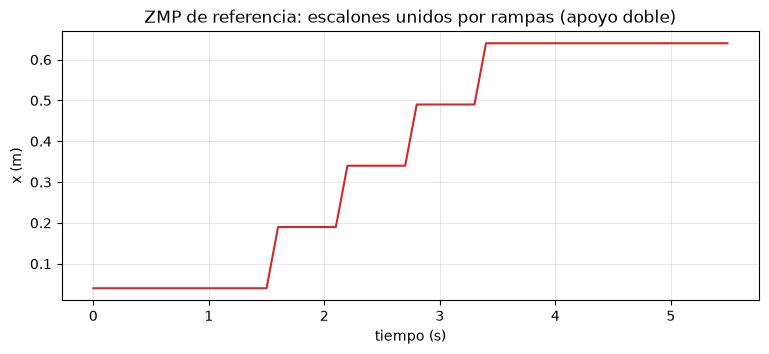

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(t, zmp_ref, color="tab:red")
ax.set(xlabel="tiempo (s)", ylabel="x (m)", title="ZMP de referencia: escalones unidos por rampas (apoyo doble)")
ax.grid(alpha=0.3)
plt.show()

Una **escalera con rampas**: cada escalón, medio segundo sobre un pie; cada rampa, el paso del peso al pie siguiente. 550 instantes, cada 10 ms, durante 5,5 s.

Ahora la pregunta central de la lección: **¿por dónde tiene que ir el centro de masas para que el ZMP siga esta escalera?**


## 3 · El carrito sobre la mesa

### Darle la vuelta al LIPM

En el NB51, la pregunta era: "dado dónde está el pie (el ZMP), ¿cómo se mueve el CdM?". La ecuación del LIPM, ẍ = ω² · (x − p), respondía. Hoy la pregunta es **al revés**: "quiero que el ZMP esté **aquí**; ¿cómo tengo que mover el CdM?". Despejando p de la misma ecuación:

```
p  =  x  −  (z₀ / g) · ẍ
```

(ẍ es la aceleración del CdM: la "x con dos puntos" es la notación de Newton para la segunda derivada, NB17b; ẋ, con un punto, es la velocidad.) Es la fórmula del ZMP del NB39: **el ZMP es la posición del CdM menos un trozo proporcional a su aceleración**. Si el CdM acelera hacia delante, el ZMP se va hacia atrás (empujas el suelo hacia atrás con el talón).

Kajita (el ingeniero japonés del AIST que diseñó el método, en 2003) lo explicaba con una imagen: el **carrito sobre la mesa**. Imagina una mesa sin patas, apoyada en un solo pie muy pequeño, y encima un carrito que puede ir adelante y atrás. Si el carrito está quieto encima del pie, la mesa no vuelca. Si el carrito **acelera**, empuja la mesa hacia el otro lado... y moviendo el carrito con cuidado puedes conseguir que la mesa no vuelque aunque el carrito no esté encima del pie. El carrito es el CdM; el punto donde la mesa "se apoya de verdad" es el ZMP.

```
          carrito (CdM) ──►  acelera
        ┌──[▓▓]────────────────┐   ← mesa (sin masa) a la altura z₀
        └──────────┬───────────┘
                   │
                  ═╧═   ← el pie: el ZMP tiene que caer aquí
```

### El intento ingenuo

¿Y si hacemos lo más obvio: poner el CdM **exactamente** donde queremos el ZMP? Calculemos qué ZMP resultaría, con la fórmula de arriba (la aceleración, con dos pendientes numéricas, `np.gradient`, P6):


In [5]:
aceleracion = np.gradient(np.gradient(zmp_ref, marcha.dt), marcha.dt)
zmp_ingenuo = zmp_ref - z0 / g * aceleracion
print("aceleración máxima del CdM:", np.abs(aceleracion).max().round(1), "m/s²")
print("el ZMP iría de", zmp_ingenuo.min().round(2), "a", zmp_ingenuo.max().round(2), "m")

aceleración máxima del CdM: 75.0 m/s²
el ZMP iría de -5.39 a 6.07 m


¡Desastre! En las esquinas de las rampas, el CdM tendría que acelerar a **75 m/s²** (casi 8 veces la gravedad), y el ZMP saldría disparado hasta **6 metros** de distancia: imposible, el pie mide 20 cm.

La lección: **el CdM no puede ir donde el ZMP**. Para que el ZMP pase al pie siguiente, el CdM tiene que haber empezado a moverse **antes**, ganando velocidad poco a poco. Igual que tú: cuando vas a dar un paso, tu cuerpo empieza a inclinarse hacia delante **antes** de que el pie se levante. Hace falta **anticiparse**. Y para anticiparse hay que **saber lo que viene**: hay que mirar el plan **hacia el futuro**. De ahí el nombre del método: **control por vista previa** (*preview control*).


## 4 · El modelo, a saltos de 10 ms

Para planificar con un ordenador, el modelo se escribe "a saltitos" de Δt = 10 ms (como en el NB07, pero exacto). Usamos como **estado** del CdM tres números: posición, velocidad y aceleración, (x, ẋ, ẍ). Y como **mando** (lo que elegimos en cada instante), la **sacudida**, u: el cambio de la aceleración por segundo (*jerk*, en inglés). ¿Por qué la sacudida y no la aceleración? Porque así la aceleración cambia **suavemente** (nunca da saltos), y con ella el ZMP y las fuerzas de los motores.

Si la sacudida es constante durante un saltito Δt, las fórmulas de la física de toda la vida (como las de la caída libre, pero un escalón más arriba) dicen exactamente cómo cambia el estado:

```
x   nueva  =  x  +  ẋ·Δt  +  ẍ·Δt²/2  +  u·Δt³/6
ẋ   nueva  =        ẋ     +  ẍ·Δt     +  u·Δt²/2
ẍ   nueva  =                 ẍ        +  u·Δt
```

Tres ecuaciones lineales: se escriben de golpe con **matrices** (P7): estado nuevo = **A** · estado + **B** · u. Y el ZMP es otra combinación lineal del estado: p = **C** · estado, con C = (1, 0, −z₀/g), la fórmula del carrito.


In [6]:
dt = marcha.dt
A = np.array([[1, dt, dt ** 2 / 2],
              [0, 1,  dt],
              [0, 0,  1]])
B = np.array([[dt ** 3 / 6], [dt ** 2 / 2], [dt]])
C = np.array([[1, 0, -z0 / g]])

estado = np.array([0.0, 0.0, 0.0])
for _ in range(100):                          # 1 s con una sacudida constante de 1 m/s³
    estado = A @ estado + B[:, 0] * 1.0
print("tras 1 s:", estado, "  (la fórmula exacta: x = t³/6 = 0,1667, ẋ = t²/2 = 0,5, ẍ = t = 1)")

tras 1 s: [0.1667 0.5    1.    ]   (la fórmula exacta: x = t³/6 = 0,1667, ẋ = t²/2 = 0,5, ẍ = t = 1)


Exacto. (Con sacudida constante, las fórmulas son exactas, no aproximadas como Euler: por eso se usa este modelo.)

Así que el problema es: **elegir la sacudida u de cada instante** para que el ZMP, C · estado, siga a la escalera. Para eso hay una herramienta de control de lo más famosa.


## 5 · Control óptimo: el LQR en tres ideas

### Idea 1: escribir lo que quieres como un número a minimizar

En vez de inventar una regla ("si el ZMP va retrasado, empuja más..."), describimos **qué es un buen movimiento** con un número, el **coste**, y dejamos que las matemáticas encuentren el mejor:

```
coste  =  suma, en todos los instantes, de   Q · (error del ZMP)²  +  R · (sacudida)²
```

- El primer término castiga que el ZMP se aparte de la referencia.
- El segundo castiga moverse a lo bruto.
- Q y R son **pesos**: deciden cuánto te importa cada cosa. Con R muy pequeño, prefieres seguir el ZMP al milímetro aunque haga falta sacudir mucho; con R grande, prefieres suavidad aunque el ZMP se aparte un poco. (Es la misma idea que las recompensas con pesos del NB44, pero en vez de aprenderlo probando, se **calcula**.)

### Idea 2: la respuesta es una regla lineal

Para sistemas lineales (como el nuestro) con coste cuadrático (errores **al cuadrado**), los matemáticos demostraron en los años 60 (Kalman, el del filtro del NB41) algo precioso: la mejor sacudida es siempre una **combinación lineal del estado**, u = −K · estado, con unos números K fijos. Esto se llama **LQR**: *Linear Quadratic Regulator*, "regulador lineal cuadrático".

### Idea 3: K sale de la ecuación de Riccati

Los números K salen de resolver una ecuación de matrices llamada **ecuación de Riccati** (por el matemático italiano Jacopo Riccati, del siglo XVIII). Su incógnita es una matriz **P** que mide "cuánto coste me queda por delante si empiezo en este estado". Y hay una forma muy sencilla de resolverla: **repetir** esta cuenta hasta que P deje de cambiar:

```
P  ←  Q + Aᵀ·P·A − Aᵀ·P·B · (R + Bᵀ·P·B)⁻¹ · Bᵀ·P·A
```

No hace falta memorizarla. Lo importante es la idea: es como calcular hacia atrás desde el futuro lejano (como el plan del DCM del NB51) hasta que el resultado se estabiliza. Normalmente se usa `scipy.linalg.solve_discrete_are`, pero no tenemos SciPy instalado y, además, así se entiende mejor.

### Un detalle: el error acumulado

Kajita añade un truco: el estado se **amplía** con una cuarta componente, la **suma de los errores** del ZMP hasta ahora (como la "I" de un PID, NB40). Así, si el modelo tuviera un pequeño error constante, el controlador lo iría corrigiendo. El estado ampliado tiene 4 números, y las matrices crecen un poco (`Aa`, `Ba`). El resto es igual.


In [7]:
def riccati(Aa, Ba, Q, R, tolerancia=1e-10, max_iter=100_000):
    P = Q.copy()
    for vuelta in range(max_iter):
        S = R + Ba.T @ P @ Ba
        P_nueva = Q + Aa.T @ P @ Aa - Aa.T @ P @ Ba @ np.linalg.solve(S, Ba.T @ P @ Aa)
        cambio = np.abs(P_nueva - P).max()
        P = P_nueva
        if cambio < tolerancia * np.abs(P).max():
            break
    else:
        raise RuntimeError("la iteración de Riccati no ha convergido")
    return P, vuelta + 1

# el estado ampliado: (suma de errores del ZMP, x, ẋ, ẍ)
Aa = np.zeros((4, 4)); Aa[0, 0] = 1; Aa[0, 1:] = C @ A; Aa[1:, 1:] = A
Ba = np.vstack([C @ B, B])
Q = np.diag([1.0, 0.0, 0.0, 0.0])
R = np.array([[1e-6]])

P, vueltas = riccati(Aa, Ba, Q, R)
print("Riccati ha convergido en", vueltas, "vueltas")

Riccati ha convergido en 484 vueltas


Dos detalles de Python:

- **`for ... else`**: el `else` de un bucle `for` se ejecuta **solo si el bucle acaba sin `break`**. Aquí: si da las 100.000 vueltas sin converger, lanzamos un error en vez de devolver una P mala en silencio. Es una construcción poco conocida (muchos programadores con años de experiencia no la usan), pero es justo lo que pide este caso. Léela como "for... y si nunca hubo break, entonces...".
- **`np.linalg.solve(S, X)`** calcula S⁻¹·X sin calcular la inversa (NB46, P7: más rápido y más preciso). Lo que en la fórmula es (R + BᵀPB)⁻¹.

Con P, las ganancias:


In [8]:
S = R + Ba.T @ P @ Ba
K = np.linalg.solve(S, Ba.T @ P @ Aa)
k_integral, k_estado = K[0, 0], K[0, 1:]
print("ganancia del error acumulado:", round(k_integral, 1))
print("ganancias del estado (x, ẋ, ẍ):", k_estado.round(1))

ganancia del error acumulado: 519.6
ganancias del estado (x, ẋ, ẍ): [28903.9  8183.5   113.4]


La regla del LQR es: sacudida = −519,6 · (suma de errores) − 28.904 · x − 8.184 · ẋ − 113 · ẍ. Números grandes porque la sacudida es una magnitud "grande" (una aceleración que cambia en 10 ms). Pero esta regla solo mira el **presente**. Falta lo más importante: el futuro.


## 6 · La vista previa: mirar al futuro

La parte genial de Kajita (en realidad, de un resultado de control de Katayama, de 1985) es que, si conoces la referencia **futura**, el controlador óptimo añade un término más: una **suma ponderada de los ZMP de referencia de los próximos instantes**:

```
sacudida  =  − k_integral · (suma de errores)  −  k_estado · estado  −  Σ  G(j) · ZMP_ref(ahora + j)
                                                                        j=1..N
```

Los pesos G(j) también salen de la P de Riccati, con otra pequeña recursión. Calculémoslos para N = 160 instantes (1,6 s de futuro):


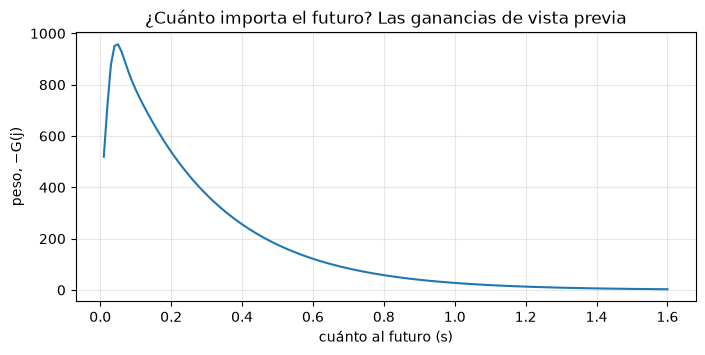

peso a 0,5 s: 170.1   a 1 s: 26.5   a 1,5 s: 4.1


In [9]:
def ganancias_vista(Aa, Ba, P, S, K, n_vista):
    cerrado = Aa - Ba @ K
    G = np.zeros(n_vista)
    G[0] = -K[0, 0]
    X = -cerrado.T @ P @ np.array([[1.0], [0], [0], [0]])
    for j in range(1, n_vista):
        G[j] = np.linalg.solve(S, Ba.T @ X)[0, 0]
        X = cerrado.T @ X
    return G

G = ganancias_vista(Aa, Ba, P, S, K, 160)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(np.arange(1, 161) * dt, -G)
ax.set(xlabel="cuánto al futuro (s)", ylabel="peso, −G(j)", title="¿Cuánto importa el futuro? Las ganancias de vista previa")
ax.grid(alpha=0.3)
plt.show()
print("peso a 0,5 s:", round(-G[50], 1), "  a 1 s:", round(-G[100], 1), "  a 1,5 s:", round(-G[150], 1))

La gráfica dice **cuánto importa cada instante del futuro** para decidir la sacudida de ahora. El peso crece primero (lo que viene dentro de un par de décimas importa mucho), y luego **se apaga**: a 0,5 s pesa 170; a 1 s, 27; a 1,5 s, solo 4. Más allá de ~1,5 s, el futuro ya casi no influye.

¿Te suena ese "apagarse"? Es la **mitad estable del NB51**: lo que pasará dentro de mucho tiempo pesa como e^(−ω·t). Con ω = 3,7, a 1,5 s eso es e^(−5,6) ≈ 0,004. **El horizonte de vista previa necesario lo marca ω**: unos 1,5-2 segundos para un humanoide.

### El controlador completo

Ahora juntamos todo en un bucle: en cada instante, calculamos el ZMP actual, sumamos el error, miramos 160 instantes al futuro (rellenando con el último valor cuando el plan se acaba) y aplicamos la sacudida:


In [10]:
def vista_previa(zmp_ref, k_integral, k_estado, G):
    n_vista = len(G)
    futuro = np.concatenate([zmp_ref, np.full(n_vista, zmp_ref[-1])])
    estado = np.array([zmp_ref[0], 0.0, 0.0])
    suma_error = 0.0
    estados, zmps = np.zeros((len(zmp_ref), 3)), np.zeros(len(zmp_ref))
    for k in range(len(zmp_ref)):
        zmp = (C @ estado)[0]
        suma_error += zmp - zmp_ref[k]
        sacudida = -k_integral * suma_error - k_estado @ estado - G @ futuro[k + 1:k + 1 + n_vista]
        estado = A @ estado + B[:, 0] * sacudida
        estados[k], zmps[k] = estado, zmp
    return estados, zmps

cdm, zmp_real = vista_previa(zmp_ref, k_integral, k_estado, G)
print("error máximo del ZMP:", np.abs(zmp_real - zmp_ref).max().round(4), "m")
print("CdM al final:", cdm[-1, 0].round(4), "m   velocidad máxima:", cdm[:, 1].max().round(3), "m/s")

error máximo del ZMP: 0.0058 m
CdM al final: 0.64 m   velocidad máxima: 0.318 m/s


El ZMP sigue a la referencia con un error máximo de **5,8 mm** (frente a los 6 metros del intento ingenuo) y el CdM acaba en 0,64 m, justo en el centro de los pies finales. (`G @ futuro[...]` es un producto escalar, NB13: la suma ponderada de los 160 valores futuros en una sola operación.)

Veámoslo:


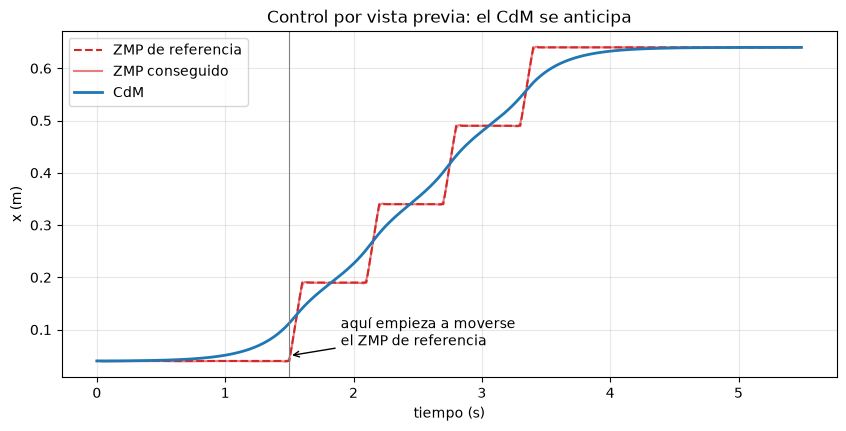

el CdM se ha movido 1 mm a los 0.44 s; el ZMP de referencia empieza a cambiar a los 1.51 s


In [11]:
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(t, zmp_ref, color="tab:red", linestyle="--", label="ZMP de referencia")
ax.plot(t, zmp_real, color="tab:red", alpha=0.6, label="ZMP conseguido")
ax.plot(t, cdm[:, 0], color="tab:blue", linewidth=2, label="CdM")
ax.axvline(1.5, color="gray", linewidth=0.8)
ax.annotate("aquí empieza a moverse\nel ZMP de referencia", xy=(1.5, 0.05), xytext=(1.9, 0.07),
            arrowprops=dict(arrowstyle="->"))
ax.set(xlabel="tiempo (s)", ylabel="x (m)", title="Control por vista previa: el CdM se anticipa")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.show()

empieza_cdm = t[np.argmax(np.abs(cdm[:, 0] - CENTRO_PIE) > 0.001)]
empieza_zmp = t[np.argmax(np.abs(zmp_ref - CENTRO_PIE) > 1e-9)]
print(f"el CdM se ha movido 1 mm a los {empieza_cdm:.2f} s; el ZMP de referencia empieza a cambiar a los {empieza_zmp:.2f} s")

Fíjate en el principio. El ZMP de referencia no cambia hasta los **1,51 s** (el primer apoyo simple es sobre el pie derecho, que ya estaba ahí). Pero el CdM empieza a moverse a los **0,44 s**: **más de un segundo antes**. Porque "ve" lo que viene.

Y un detalle contraintuitivo: justo antes de la primera rampa, el ZMP conseguido se va un poquito **hacia atrás** (1,5 mm por debajo de 0,04) antes de ir hacia delante. Para que el CdM empiece a avanzar, hay que empujar el suelo hacia atrás (el ZMP se va al talón; el carrito acelera hacia delante y la mesa tiende a volcar hacia atrás). Es el mismo "empujoncito hacia atrás para arrancar" que vimos en la fase de arranque del NB51.

Durante cada apoyo simple, el CdM pasa **por encima** del pie de apoyo, y en el apoyo doble cruza hacia el siguiente: la forma de "S" de cada escalón. Es la misma marcha del NB51, pero ahora con un ZMP que **no salta**.

### ¿Cuánto futuro hace falta?

Comprobemos lo de ω: repitamos con horizontes de vista previa cada vez más largos:


In [12]:
for n_vista in [10, 20, 40, 80, 120, 160]:
    G_n = ganancias_vista(Aa, Ba, P, S, K, n_vista)
    _, zmp_n = vista_previa(zmp_ref, k_integral, k_estado, G_n)
    print(f"mirando {n_vista * dt:.1f} s al futuro: error máximo del ZMP {np.abs(zmp_n - zmp_ref).max() * 100:6.2f} cm")

mirando 0.1 s al futuro: error máximo del ZMP  59.69 cm
mirando 0.2 s al futuro: error máximo del ZMP  41.16 cm
mirando 0.4 s al futuro: error máximo del ZMP  19.57 cm
mirando 0.8 s al futuro: error máximo del ZMP   4.42 cm
mirando 1.2 s al futuro: error máximo del ZMP   1.00 cm
mirando 1.6 s al futuro: error máximo del ZMP   0.58 cm


Mirando solo 0,1 s al futuro, el ZMP se aparta **60 cm**: imposible. Con 0,4 s, 20 cm, todavía fuera del pie. Con 0,8 s, 4,4 cm; con 1,2 s, 1 cm; con 1,6 s, 0,6 cm. **Mirar al futuro no es un lujo: sin él, no hay forma de andar.** Y a partir de 1,2-1,6 s mejora poco: el horizonte "natural" que marca ω.

Esto responde una pregunta de entrevista: *"¿qué pasa si el plan de pisadas cambia de repente (por ejemplo, el robot decide girar)?"*. El controlador necesita conocer el cambio con **al menos un segundo** de antelación. Por eso, en un robot real, el plan de pisadas se mantiene siempre con varios pasos por delante.


## 7 · Los pies en el aire

Los pies, como en el NB51: mientras uno está apoyado, el otro vuela de su pisada anterior a la siguiente con el perfil **quíntico** en horizontal y el bulto **64σ³(1 − σ)³** en vertical, aquí de 4 cm de altura. Ahora trabajamos con los **tobillos** (que es lo que mueve la cinemática inversa): el tobillo está 4 cm detrás del centro de la pisada, y a 6,5 cm del suelo cuando el pie está apoyado.

Guardamos los dos pies en un único array de **tres dimensiones**: (instante, pie, coordenada). Por ejemplo, `pies[100, 1, 0]` es la x del pie izquierdo en el instante 100. Las tablas de más de 2 dimensiones dan un poco de vértigo al principio, pero son solo "tablas de tablas" (P6):


In [13]:
ALTURA_TOBILLO = 0.065

def quintico(s):
    return 10 * s ** 3 - 15 * s ** 4 + 6 * s ** 5

def pies_en_el_tiempo(m: Marcha):
    p = m.pisadas() - CENTRO_PIE                         # de centros de pisada a tobillos
    n = round(sum(d for _, _, d in tramos(m)) / m.dt)
    pies = np.zeros((n, 2, 2))
    pies[:, :, 0] = p[0]
    pies[:, :, 1] = ALTURA_TOBILLO
    inicio = m.t_inicio
    for k in range(len(p) - 1):
        vuela = 1 - k % 2                                # paso 0: apoya el derecho (0), vuela el izquierdo (1)
        i0, i1 = round(inicio / m.dt), round((inicio + m.t_simple) / m.dt)
        s = np.arange(i1 - i0) / (i1 - i0)
        desde = pies[i0 - 1, vuela, 0]
        pies[i0:i1, vuela, 0] = desde + (p[k + 1] - desde) * quintico(s)
        pies[i0:i1, vuela, 1] = ALTURA_TOBILLO + m.altura_paso * 64 * s ** 3 * (1 - s) ** 3
        pies[i1:, vuela, 0] = p[k + 1]
        inicio += m.t_simple + m.t_doble
    return pies

pies = pies_en_el_tiempo(marcha)
print("forma:", pies.shape, "  tobillos al final:", pies[-1])

forma: (550, 2, 2)   tobillos al final: [[0.6   0.065]
 [0.6   0.065]]


(`sum(d for _, _, d in tramos(m))` suma las duraciones con una **expresión generadora**, P4: la tercera cosa de cada tramo; el `_` es el nombre de costumbre para "esto no lo uso". `pies[i1:, vuela, 0] = p[k + 1]` deja el pie en su pisada nueva **desde que aterriza hasta el final**: si luego vuelve a volar, el paso siguiente lo sobrescribe.)

Al final, los dos tobillos en x = 0,6 y a 6,5 cm de altura: los pies juntos.


## 8 · Cinemática inversa de la pierna, a mano

### El problema

Ya tenemos dónde debe estar el CdM y dónde los tobillos, en cada instante. Pero a los motores no se les puede decir "pon el tobillo en x = 0,3": solo entienden **ángulos**. Necesitamos la **cinemática inversa** (NB46): de posiciones a ángulos.

En el NB46 la resolvimos con un método **numérico** general (el jacobiano y mínimos cuadrados amortiguados, iterando). Para una pierna plana de dos eslabones hay algo mejor: una **fórmula exacta**, con un poco de geometría de triángulos. Es la pregunta de pizarra más típica de las entrevistas de robótica.

### La ley del coseno

Un triángulo cualquiera con lados a, b y c, y llamamos γ (gamma) al ángulo que forman a y b. La **ley del coseno** dice:

```
c²  =  a² + b² − 2·a·b·cos(γ)
```

Si γ es un ángulo recto (90°), cos(γ) = 0 y queda c² = a² + b²: ¡el **teorema de Pitágoras**! La ley del coseno es Pitágoras para triángulos que no tienen ángulo recto. Si γ es pequeño, el triángulo está "cerrado" y c es corto; si γ se acerca a 180°, el triángulo se "abre" y c se acerca a a + b.

### La pierna como triángulo

La cadera, la rodilla y el tobillo forman un triángulo: lado a = muslo (0,4 m), lado b = pierna (0,4 m), y el tercer lado, c = **D**, la distancia de la cadera al tobillo, que **sabemos** (tenemos las dos posiciones).

```
      cadera ●
              \  muslo (0,4)
               \
          D     ● rodilla        el ángulo de la rodilla en el triángulo es γ;
               /                 la articulación mide cuánto se DOBLA: r = −(180° − γ)
              /  pierna (0,4)
     tobillo ●
```

La rodilla de Zancudo mide cuánto se **dobla** respecto a la pierna recta, con números negativos (NB42): r = 0 es la pierna estirada (γ = 180°). Como cos(180° − γ) = −cos(γ), la ley del coseno se convierte en:

```
cos(r)  =  (D² − muslo² − pierna²) / (2 · muslo · pierna)
```

Comprobación rápida: con la pierna estirada, D = 0,8 → cos(r) = (0,64 − 0,16 − 0,16)/0,32 = 1 → r = 0 ✓.

Despejamos r con el **arcocoseno** (`math.acos`, la operación inversa del coseno, NB36) y le ponemos signo negativo (la rodilla de Zancudo se dobla hacia ese lado; con el signo contrario saldría la otra solución, la rodilla doblada al revés, como la "rodilla" de un flamenco, que en realidad es su tobillo).

### La cadera y el tobillo

- **Cadera**: primero, el ángulo φ (fi) de la línea cadera → tobillo respecto a la vertical, con `math.atan2(dx, dz)` (NB36: el ángulo de un vector, sin líos de cuadrantes). Como muslo y pierna miden lo mismo, el triángulo es **isósceles**, y el muslo está girado **la mitad del doblez** respecto a esa línea: cadera = φ − r/2.
- **Tobillo**: queremos la planta **horizontal**. El ángulo de la planta es la suma de los tres ángulos de la pierna, así que el tobillo tiene que deshacer los otros dos: tobillo = −(cadera + rodilla). (Es lo que cumplía la postura `agachado` del NB50: 0,5 − 1 + 0,5 = 0.)


In [14]:
MUSLO = PIERNA = 0.4

def ik_pierna(cadera_x, cadera_z, tobillo_x, tobillo_z):
    dx, dz = tobillo_x - cadera_x, cadera_z - tobillo_z
    coseno = (dx ** 2 + dz ** 2 - MUSLO ** 2 - PIERNA ** 2) / (2 * MUSLO * PIERNA)
    rodilla = -math.acos(min(1.0, max(-1.0, coseno)))
    cadera = math.atan2(dx, dz) - rodilla / 2
    return cadera, rodilla, -(cadera + rodilla)

print(ik_pierna(0.0, 0.767, 0.0, ALTURA_TOBILLO))

(0.5001721829049757, -1.0003443658099513, 0.5001721829049757)


Con la cadera justo encima del tobillo, a la altura de andar: cadera 0,500, rodilla −1,000, tobillo 0,500. ¡Exactamente la postura `agachado` del NB50! (No es casualidad: la altura de cadera de andar, 0,767 m, la sacamos de esa postura.)

El `min(1.0, max(-1.0, coseno))` **recorta** el coseno al intervalo [−1, 1]. Si alguien pide un tobillo **más lejos** de lo que llega la pierna (D > 0,8), el coseno saldría mayor que 1, y `math.acos` daría un error (no existe ningún ángulo con coseno 1,2). Con el recorte, la pierna se queda **estirada del todo**, apuntando hacia el objetivo: lo más cerca que puede llegar. Es programación defensiva (NB46).

La prueba de fuego: le damos los ángulos a MuJoCo y le preguntamos dónde queda el tobillo (el origen del cuerpo `pie_d`) y si la planta está horizontal:


In [15]:
datos = mujoco.MjData(zancudo)
cadera_x, cadera_z = 0.0, 0.767
for objetivo in [(0.10, 0.065), (-0.15, 0.065), (0.05, 0.15)]:
    datos.qpos[:] = 0
    datos.qpos[1] = cadera_z - 0.865                      # baja el torso hasta la altura de cadera pedida
    datos.qpos[3:6] = ik_pierna(cadera_x, cadera_z, *objetivo)
    mujoco.mj_kinematics(zancudo, datos)
    tobillo = datos.xpos[zancudo.body("pie_d").id]
    giro_pie = datos.xmat[zancudo.body("pie_d").id].reshape(3, 3)
    print(f"pedido {objetivo} → MuJoCo ({tobillo[0]:.6f}, {tobillo[2]:.6f})   planta inclinada {math.atan2(giro_pie[0, 2], giro_pie[2, 2]):+.1e} rad")

pedido (0.1, 0.065) → MuJoCo (0.100000, 0.065000)   planta inclinada -5.5e-17 rad
pedido (-0.15, 0.065) → MuJoCo (-0.150000, 0.065000)   planta inclinada -3.6e-17 rad
pedido (0.05, 0.15) → MuJoCo (0.050000, 0.150000)   planta inclinada +1.4e-17 rad


Exacto hasta el último decimal, y la planta perfectamente horizontal (una inclinación de 10⁻¹⁶ es cero con los errores de redondeo del ordenador). Una fórmula de 4 líneas que hace en un instante lo que el método numérico del NB46 hacía con iteraciones. **Siempre que exista una solución analítica, úsala**: es exacta, rapidísima y predecible. Las numéricas, para cuando no la hay (robots de muchas articulaciones, objetivos de orientación en 3D...).

(La inclinación de la planta se saca de la matriz de rotación del pie, NB46: `xmat` son los 9 números de esa matriz, y con `atan2` de dos de ellos sale el ángulo de giro alrededor del eje y.)


## 9 · Cinemática inversa del centro de masas

### El CdM no es la cadera

Falta una pieza. El control por vista previa nos dice dónde tiene que estar el **centro de masas**. Pero en la cinemática inversa elegimos dónde está la **cadera** (el torso). Y no son lo mismo: el CdM es la media de todas las masas (NB38), y las piernas pesan 11,6 de los 23,6 kg. Si un pie está adelantado, el CdM se adelanta un poco respecto a la cadera.

Así que hay que resolver otra ecuación: **¿dónde pongo la cadera para que el CdM quede donde quiero?** No hay fórmula sencilla (depende de cómo estén las dos piernas), pero sí una forma de calcular "dada la cadera, ¿dónde queda el CdM?": colocar a Zancudo con la IK de las dos piernas y pedirle el CdM a MuJoCo (`mj_kinematics` + `mj_comPos`, NB46):


In [16]:
ALTURA_CADERA = 0.767

def cdm_con_cadera(x, pie_d, pie_i):
    q = np.zeros(zancudo.nq)
    q[0], q[1] = x, ALTURA_CADERA - 0.865
    q[3:6] = ik_pierna(x, ALTURA_CADERA, *pie_d)
    q[6:9] = ik_pierna(x, ALTURA_CADERA, *pie_i)
    datos.qpos[:] = q
    mujoco.mj_kinematics(zancudo, datos)
    mujoco.mj_comPos(zancudo, datos)
    return q, datos.subtree_com[1][0]

pie_d, pie_i = (0.10, 0.065), (0.35, 0.065)            # una postura de apoyo doble con los pies separados
objetivo = 0.2
_, cdm_x = cdm_con_cadera(objetivo, pie_d, pie_i)
print(f"con la cadera en {objetivo}, el CdM queda en {cdm_x:.4f}: {abs(cdm_x - objetivo) * 100:.1f} cm de diferencia")

con la cadera en 0.2, el CdM queda en 0.2469: 4.7 cm de diferencia


4,7 cm: no es un detalle. Hay que **buscar** la cadera.

### Primer intento: corregir con el error

La idea más simple: si el CdM se ha quedado 4,7 cm lejos, movemos la cadera 4,7 cm, y repetimos. Es un **método de punto fijo**:


In [17]:
x = objetivo
for vuelta in range(5):
    _, cdm_x = cdm_con_cadera(x, pie_d, pie_i)
    error = objetivo - cdm_x
    print(f"vuelta {vuelta + 1}: cadera {x:.5f}   error del CdM {abs(error):.2e} m")
    x += error

vuelta 1: cadera 0.20000   error del CdM 4.69e-02 m
vuelta 2: cadera 0.15311   error del CdM 1.13e-02 m
vuelta 3: cadera 0.14185   error del CdM 2.58e-03 m
vuelta 4: cadera 0.13927   error del CdM 5.84e-04 m
vuelta 5: cadera 0.13868   error del CdM 1.32e-04 m


Funciona, pero despacio: el error solo se divide entre ~4,4 en cada vuelta. ¿Por qué? Porque al mover la cadera 1 cm, el CdM **no** se mueve 1 cm: los pies se quedan quietos en el suelo, y solo se mueve una parte del cuerpo. El CdM se mueve unos **0,77 cm** por cada cm de cadera (la **pendiente** de "CdM en función de la cadera", NB16). Al corregir con todo el error, nos quedamos cortos una y otra vez.

### Segundo intento: el método de la secante

La solución es tener en cuenta la pendiente: **corregir con el error dividido entre la pendiente**. Es el **método de Newton** que anunciamos en el NB17b. Y como la pendiente no la conocemos, la **estimamos** con los dos últimos intentos: (cambio del error) / (cambio de la cadera). Eso es el **método de la secante** (la "secante" es la recta que pasa por dos puntos de una curva):


In [18]:
x_a = objetivo
_, cdm_x = cdm_con_cadera(x_a, pie_d, pie_i)
error_a = objetivo - cdm_x
x_b = x_a + error_a                                       # el primer paso, como antes
for vuelta in range(5):
    _, cdm_x = cdm_con_cadera(x_b, pie_d, pie_i)
    error_b = objetivo - cdm_x
    print(f"vuelta {vuelta + 1}: cadera {x_b:.8f}   error del CdM {abs(error_b):.2e} m")
    if abs(error_b) < 1e-12:
        break
    x_a, error_a, x_b = x_b, error_b, x_b + error_b * (x_b - x_a) / (error_a - error_b)

vuelta 1: cadera 0.15311304   error del CdM 1.13e-02 m
vuelta 2: cadera 0.13828204   error del CdM 1.77e-04 m
vuelta 3: cadera 0.13851158   error del CdM 6.70e-07 m
vuelta 4: cadera 0.13851071   error del CdM 3.99e-11 m
vuelta 5: cadera 0.13851071   error del CdM 2.78e-17 m


1 cm, 0,18 mm, 0,7 micras, 0,00004 micras... En cada vuelta, el número de cifras correctas **se multiplica** (casi se duplica): es la **convergencia superlineal** de los métodos tipo Newton. En 3 vueltas, mejor que un micrómetro. La cadera tiene que ir en **0,1385**, 6 cm por detrás del CdM.

(La última línea es una asignación múltiple, P1, que avanza los dos últimos intentos de golpe: el "b" pasa a ser el "a", y el nuevo "b" es la corrección dividida entre la pendiente estimada, (error_a − error_b) / (x_b − x_a).)

Con esto ya tenemos todas las piezas: vista previa → CdM → secante → cadera → IK de las piernas → ángulos. Antes de ponerlas a trabajar juntas, vamos a **ordenarlas**.


## 10 · Python: de notebook a librería

### El problema

Mira lo que hemos escrito hasta aquí: una docena de funciones repartidas por celdas, variables globales (`A`, `B`, `C`, `zancudo`, `datos`...) que unas funciones usan sin pedirlas, y ninguna forma de usar todo esto desde **otro** notebook. En el NB53 querremos andar en 3D, en el NB55 con empujones al azar... ¿copiamos y pegamos las celdas? Eso es el principio del desastre: cuando arregles un fallo en una copia, las otras seguirán rotas.

La solución profesional es convertir el código en una **librería**: un **paquete** de Python, una carpeta con ficheros `.py` que se importa con `import`. En el P4 hiciste módulos sueltos (un fichero `.py`) y en el NB43 usamos `zancudo_env.py`. Un paquete es el siguiente escalón: **varios módulos organizados**, con una puerta de entrada.

### La anatomía de un paquete

```
notebooks/
└── andar/                 ← el paquete: una carpeta...
    ├── __init__.py        ← ...con este fichero. Es la "puerta": se ejecuta al hacer `import andar`
    ├── plan.py            ← módulo: pisadas, ZMP de referencia, vista previa, pies
    ├── cinematica.py      ← módulo: IK de la pierna y del CdM
    └── control.py         ← módulo: servos, ejecutar posturas, paso de captura
```

Las decisiones de diseño, que son lo importante (y lo que te preguntarán en una revisión de código):

1. **Un tema por módulo** (*cohesión*): todo lo del plan junto; todo lo de la IK junto. Si mañana cambias la forma de planificar, solo tocas `plan.py`.
2. **Dependencias en una sola dirección**: `control` usa `cinematica` y `plan`; `cinematica` no usa `control`; `plan` no usa a nadie. Si dos módulos se importaran **mutuamente** (A importa B y B importa A), Python se liaría: es el famoso error de **importación circular**.
3. **Nada de variables globales escondidas**: todo lo que una función necesita, lo recibe como argumento (el modelo, la marcha, las ganancias...). Los datos que van juntos, en una `dataclass` (`Marcha`, `Ganancias`, `Registro`).
4. **Interfaz pública pequeña**: el `__init__.py` dice qué se puede usar desde fuera (en una lista llamada `__all__`). Las funciones internas empiezan por **guion bajo** (`_tramos`, `_quintico`): es el convenio de Python para "esto es privado, no lo uses desde fuera" (P3). Python no lo impide, pero avisa.
5. **Documentación y tipos** en todo lo público (P2, P5): quien use la librería debería poder hacerlo leyendo solo los *docstrings*.

### Escribir los ficheros desde el notebook

Jupyter tiene una "orden mágica" para escribir una celda en un fichero: **`%%writefile ruta`** en la primera línea. (Las órdenes que empiezan por `%` o `%%` no son Python: son de Jupyter. Con `%%` actúan sobre la celda entera.) Primero, la carpeta:


In [19]:
from pathlib import Path
Path("andar").mkdir(exist_ok=True)
print("carpeta lista:", Path("andar").resolve())

carpeta lista: /home/gregori/dev/robotica/notebooks/andar


Y ahora, los cuatro ficheros. Son el mismo código de arriba, **ordenado y pulido**: con tipos, *docstrings*, sin globales, y con algunas piezas nuevas que explicamos debajo de cada uno. Primero, **`plan.py`**:


In [20]:
%%writefile andar/plan.py
"""Plan de la marcha: pisadas, ZMP de referencia y control por vista previa (Kajita, 2003)."""
from __future__ import annotations

import logging
from dataclasses import dataclass

import numpy as np
from numpy.typing import NDArray

G = 9.81
CENTRO_PIE = 0.04          # el centro de la planta está 4 cm por delante del tobillo
ALTURA_TOBILLO = 0.065     # altura del tobillo con el pie apoyado

logger = logging.getLogger(__name__)


@dataclass(frozen=True)
class Marcha:
    """Parámetros de una marcha en línea recta (todo en metros y segundos)."""
    largo: float = 0.15
    n_pasos: int = 4
    t_simple: float = 0.5
    t_doble: float = 0.1
    t_inicio: float = 1.0
    t_final: float = 1.5
    altura_paso: float = 0.04
    z0: float = 0.71
    dt: float = 0.01

    def pisadas(self) -> NDArray[np.float64]:
        """Centros de las pisadas: la 0 es el pie derecho donde ya está; la última junta los pies."""
        xs = np.arange(self.n_pasos + 1) * self.largo
        return np.append(xs, xs[-1]) + CENTRO_PIE


@dataclass(frozen=True)
class Ganancias:
    A: NDArray[np.float64]
    B: NDArray[np.float64]
    C: NDArray[np.float64]
    k_integral: float
    k_estado: NDArray[np.float64]
    vista: NDArray[np.float64]


def _tramos(m: Marcha) -> list[tuple[float, float, float]]:
    """(ZMP al empezar, ZMP al acabar, duración) de cada tramo de la marcha."""
    p = m.pisadas()
    tramos = [(p[0], p[0], m.t_inicio)]
    for k in range(len(p) - 1):
        tramos.append((p[k], p[k], m.t_simple))       # apoyo simple sobre el pie k
        tramos.append((p[k], p[k + 1], m.t_doble))    # apoyo doble: el ZMP pasa al pie k + 1
    tramos.append((p[-1], p[-1], m.t_final))
    return tramos


def zmp_de_referencia(m: Marcha) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    """Instantes y ZMP de referencia, con rampas en los apoyos dobles."""
    trozos = []
    for inicio, fin, duracion in _tramos(m):
        n = round(duracion / m.dt)
        trozos.append(inicio + (fin - inicio) * np.arange(n) / n)
    zmp = np.concatenate(trozos)
    return np.arange(len(zmp)) * m.dt, zmp


def ganancias_vista_previa(z0: float, dt: float, n_vista: int, q: float = 1.0, r: float = 1e-6,
                           tolerancia: float = 1e-10, max_iter: int = 100_000) -> Ganancias:
    """Ganancias del control por vista previa: Riccati resuelta por iteración."""
    A = np.array([[1, dt, dt ** 2 / 2], [0, 1, dt], [0, 0, 1]])
    B = np.array([[dt ** 3 / 6], [dt ** 2 / 2], [dt]])
    C = np.array([[1, 0, -z0 / G]])
    Aa = np.zeros((4, 4)); Aa[0, 0] = 1; Aa[0, 1:] = C @ A; Aa[1:, 1:] = A
    Ba = np.vstack([C @ B, B])
    Q = np.diag([q, 0.0, 0.0, 0.0])
    R = np.array([[r]])
    P = Q.copy()
    for vuelta in range(max_iter):
        S = R + Ba.T @ P @ Ba
        P_nueva = Q + Aa.T @ P @ Aa - Aa.T @ P @ Ba @ np.linalg.solve(S, Ba.T @ P @ Aa)
        cambio = np.abs(P_nueva - P).max()
        P = P_nueva
        if cambio < tolerancia * np.abs(P).max():
            break
    else:
        raise RuntimeError("la iteración de Riccati no ha convergido")
    logger.debug("Riccati: %d vueltas", vuelta + 1)
    S = R + Ba.T @ P @ Ba
    K = np.linalg.solve(S, Ba.T @ P @ Aa)
    cerrado = Aa - Ba @ K
    vista = np.zeros(n_vista)
    vista[0] = -K[0, 0]
    X = -cerrado.T @ P @ np.array([[1.0], [0], [0], [0]])
    for j in range(1, n_vista):
        vista[j] = np.linalg.solve(S, Ba.T @ X)[0, 0]
        X = cerrado.T @ X
    return Ganancias(A, B, C, K[0, 0], K[0, 1:], vista)


def vista_previa(zmp_ref: NDArray[np.float64], g: Ganancias, x0: float | None = None
                 ) -> tuple[NDArray[np.float64], NDArray[np.float64]]:
    """Estados del CdM (posición, velocidad, aceleración) y ZMP resultante, para un ZMP de referencia."""
    n_vista = len(g.vista)
    futuro = np.concatenate([zmp_ref, np.full(n_vista, zmp_ref[-1])])
    estado = np.array([zmp_ref[0] if x0 is None else x0, 0.0, 0.0])
    suma_error = 0.0
    estados, zmps = np.zeros((len(zmp_ref), 3)), np.zeros(len(zmp_ref))
    for k in range(len(zmp_ref)):
        zmp = (g.C @ estado)[0]
        suma_error += zmp - zmp_ref[k]
        sacudida = -g.k_integral * suma_error - g.k_estado @ estado - g.vista @ futuro[k + 1:k + 1 + n_vista]
        estado = g.A @ estado + g.B[:, 0] * sacudida
        estados[k], zmps[k] = estado, zmp
    return estados, zmps


def _quintico(s):
    return 10 * s ** 3 - 15 * s ** 4 + 6 * s ** 5


def pies_en_el_tiempo(m: Marcha) -> NDArray[np.float64]:
    """Tobillos (x, z) de los dos pies en cada instante: forma (n, 2, 2) = (instante, pie, coordenada)."""
    p = m.pisadas() - CENTRO_PIE
    n = round(sum(d for _, _, d in _tramos(m)) / m.dt)
    pies = np.zeros((n, 2, 2))
    pies[:, :, 0] = p[0]
    pies[:, :, 1] = ALTURA_TOBILLO
    inicio = m.t_inicio
    for k in range(len(p) - 1):
        vuela = 1 - k % 2                                   # paso 0: apoya el derecho, vuela el izquierdo
        i0, i1 = round(inicio / m.dt), round((inicio + m.t_simple) / m.dt)
        s = np.arange(i1 - i0) / (i1 - i0)
        desde = pies[i0 - 1, vuela, 0]
        pies[i0:i1, vuela, 0] = desde + (p[k + 1] - desde) * _quintico(s)
        pies[i0:i1, vuela, 1] = ALTURA_TOBILLO + m.altura_paso * 64 * s ** 3 * (1 - s) ** 3
        pies[i1:, vuela, 0] = p[k + 1]
        inicio += m.t_simple + m.t_doble
    return pies

Overwriting andar/plan.py


Lo nuevo respecto a las celdas de arriba:

- **`from __future__ import annotations`**: hace que los tipos se lean como texto y no se evalúen al definir la función. Permite escribir `float | None` en versiones antiguas de Python, y es una costumbre muy extendida en librerías.
- **`logger = logging.getLogger(__name__)`**: un "registrador" con el nombre del módulo (`andar.plan`). Lo explicamos a fondo en la sección 11. Aquí se usa para contar, a nivel de detalle (`debug`), cuántas vueltas dio Riccati.
- **`Ganancias`**: una `dataclass` congelada que guarda todo lo que necesita la vista previa (las matrices y las ganancias). Así `vista_previa` lo recibe como **un** argumento, en vez de depender de `A`, `B` y `C` globales.
- **`_tramos` y `_quintico`** empiezan por guion bajo: son internos.
- Todo el ajuste de Riccati vive dentro de `ganancias_vista_previa`, que solo pide lo que de verdad cambia de un robot a otro: z₀, Δt, el horizonte y los pesos.

Ahora **`cinematica.py`**:


In [21]:
%%writefile andar/cinematica.py
"""Cinemática inversa de Zancudo: la pierna, analítica; el centro de masas, por iteración."""
from __future__ import annotations

import logging
import math

import mujoco
import numpy as np
from numpy.typing import NDArray

MUSLO = PIERNA = 0.4
ALTURA_TORSO = 0.865       # altura de la cadera con las piernas estiradas (qpos[1] = 0)

logger = logging.getLogger(__name__)


def ik_pierna(cadera_x: float, cadera_z: float, tobillo_x: float, tobillo_z: float) -> tuple[float, float, float]:
    """Ángulos (cadera, rodilla, tobillo) que ponen el tobillo en su sitio con la planta horizontal."""
    dx, dz = tobillo_x - cadera_x, cadera_z - tobillo_z
    coseno = (dx ** 2 + dz ** 2 - MUSLO ** 2 - PIERNA ** 2) / (2 * MUSLO * PIERNA)
    rodilla = -math.acos(min(1.0, max(-1.0, coseno)))
    cadera = math.atan2(dx, dz) - rodilla / 2
    return cadera, rodilla, -(cadera + rodilla)


class Cinematica:
    """Calcula posturas completas de Zancudo (torso recto, a altura fija) con un CdM dado."""

    def __init__(self, modelo: mujoco.MjModel, altura_cadera: float = 0.767, tolerancia: float = 1e-7,
                 max_iter: int = 20):
        self.modelo = modelo
        self.datos = mujoco.MjData(modelo)          # unos datos propios: no tocamos los de la simulación
        self.altura_cadera = altura_cadera
        self.tolerancia, self.max_iter = tolerancia, max_iter

    def _postura_con_cadera(self, x: float, pie_d, pie_i) -> tuple[NDArray[np.float64], float]:
        """Postura con la cadera en x, y el CdM (x) que resulta."""
        q = np.zeros(self.modelo.nq)
        q[0], q[1] = x, self.altura_cadera - ALTURA_TORSO
        q[3:6] = ik_pierna(x, self.altura_cadera, *pie_d)
        q[6:9] = ik_pierna(x, self.altura_cadera, *pie_i)
        self.datos.qpos[:] = q
        mujoco.mj_kinematics(self.modelo, self.datos)
        mujoco.mj_comPos(self.modelo, self.datos)
        return q, self.datos.subtree_com[1][0]

    def postura(self, cdm_x: float, pie_d, pie_i, cadera_x: float | None = None) -> NDArray[np.float64]:
        """qpos con los tobillos en pie_d y pie_i (x, z) y el CdM en cdm_x (método de la secante)."""
        x_a = cdm_x if cadera_x is None else cadera_x
        q, cdm = self._postura_con_cadera(x_a, pie_d, pie_i)
        error_a = cdm_x - cdm
        x_b = x_a + error_a
        for _ in range(self.max_iter):
            q, cdm = self._postura_con_cadera(x_b, pie_d, pie_i)
            error_b = cdm_x - cdm
            if abs(error_b) < self.tolerancia or error_a == error_b:
                return q
            x_a, error_a, x_b = x_b, error_b, x_b + error_b * (x_b - x_a) / (error_a - error_b)
        logger.warning("la IK del CdM no converge: pedido %.4f m, error %.1e m (¿pierna casi estirada?)",
                       cdm_x, error_b)
        return q

    def trayectoria(self, cdm: NDArray[np.float64], pies: NDArray[np.float64]) -> NDArray[np.float64]:
        """Una postura por instante: cdm (n,), pies (n, 2, 2) → (n, nq)."""
        posturas = np.zeros((len(cdm), self.modelo.nq))
        cadera_x = None
        for k in range(len(cdm)):
            posturas[k] = self.postura(cdm[k], pies[k, 0], pies[k, 1], cadera_x)
            cadera_x = posturas[k, 0]
        return posturas

Overwriting andar/cinematica.py


- **`Cinematica` es una clase** (P3) porque tiene **estado** que conviene guardar: el modelo y unos **`MjData` propios**. Muy importante: la IK usa sus propios datos para "colocar" a Zancudo y medir su CdM. Si usara los mismos datos que la simulación, ¡cada cálculo de IK teletransportaría al robot que está andando! (Es un fallo real y muy típico.)
- `postura` es la secante de arriba, con dos defensas: si las dos últimas correcciones dan el mismo error (`error_a == error_b`), no puede dividir entre cero; y si no converge (la postura es **imposible**, por ejemplo con la pierna estirada del todo), **avisa** con `logger.warning` y devuelve lo mejor que encontró, en vez de colgarse o lanzar un error que pare al robot.
- `trayectoria` arranca cada búsqueda en la cadera del instante anterior (`cadera_x`): como de un instante al siguiente apenas cambia, la secante converge en una o dos vueltas. Usar la solución anterior como punto de partida se llama **arranque en caliente** (*warm start*, NB45).

Y **`control.py`**, que todavía no hemos explicado (lo haremos en las secciones 12 a 14); de momento, solo fíjate en su estructura:


In [22]:
%%writefile andar/control.py
"""Ejecutar posturas con los servos de Zancudo, y recuperarse de empujones con un paso de captura."""
from __future__ import annotations

import logging
import math
from collections.abc import Callable
from dataclasses import dataclass
from enum import Enum, auto

import mujoco
import numpy as np
from numpy.typing import NDArray

from .cinematica import Cinematica, ik_pierna, ALTURA_TORSO
from .plan import G, CENTRO_PIE, ALTURA_TOBILLO

logger = logging.getLogger(__name__)

TALON, PUNTA = -0.06, 0.14     # la planta, respecto al tobillo


def configurar_servos(modelo: mujoco.MjModel, kp: float, kv: float) -> None:
    """Cambia la rigidez (kp) y la amortiguación (kv) de todos los servos de posición."""
    modelo.actuator_gainprm[:, 0] = kp
    modelo.actuator_biasprm[:, 1] = -kp
    modelo.actuator_biasprm[:, 2] = -kv


def se_ha_caido(datos: mujoco.MjData) -> bool:
    return abs(datos.qpos[2]) > 0.6 or datos.qpos[1] < -0.35


@dataclass
class Registro:
    t: NDArray[np.float64]
    cdm: NDArray[np.float64]
    tobillos: NDArray[np.float64]       # (n, 2): x de los tobillos derecho e izquierdo
    error_q: NDArray[np.float64]        # error máximo de las articulaciones en cada instante
    cae_en: float | None = None


def ejecutar(modelo: mujoco.MjModel, posturas: NDArray[np.float64], dt: float, prealimentar: bool = True,
             empujon: tuple[float, float] | None = None,
             al_paso: Callable[[mujoco.MjData], None] | None = None) -> Registro:
    """Sigue las posturas con los servos. empujon = (fuerza en N, instante en s), durante 0,1 s.

    Si se da `al_paso`, se le llama con los datos tras cada instante (para grabar, medir...).
    """
    datos = mujoco.MjData(modelo)
    datos.qpos[:] = posturas[0]
    datos.ctrl[:] = posturas[0, 3:]
    mujoco.mj_forward(modelo, datos)
    velocidades = np.gradient(posturas, dt, axis=0)
    kv_kp = -modelo.actuator_biasprm[0, 2] / modelo.actuator_gainprm[0, 0]
    subpasos = round(dt / modelo.opt.timestep)
    torso = modelo.body("torso").id
    pies = [modelo.body("pie_d").id, modelo.body("pie_i").id]
    n = len(posturas)
    reg = Registro(np.arange(n) * dt, np.full(n, np.nan), np.full((n, 2), np.nan), np.full(n, np.nan))
    for k in range(n):
        datos.ctrl[:] = posturas[k, 3:] + (kv_kp * velocidades[k, 3:] if prealimentar else 0.0)
        if empujon is not None:
            fuerza, instante = empujon
            datos.xfrc_applied[torso, 0] = fuerza if instante <= k * dt < instante + 0.1 else 0.0
        for _ in range(subpasos):
            mujoco.mj_step(modelo, datos)
        reg.cdm[k] = datos.subtree_com[1][0]
        reg.tobillos[k] = [datos.xpos[p][0] for p in pies]
        reg.error_q[k] = np.abs(datos.qpos[3:] - posturas[k, 3:]).max()
        if al_paso is not None:
            al_paso(datos)
        if se_ha_caido(datos):
            reg.cae_en = k * dt
            logger.info("se ha caído a los %.2f s", reg.cae_en)
            break
    return reg


class Estado(Enum):
    DE_PIE = auto()
    PASO = auto()


class PasoDeCaptura:
    """Zancudo de pie que, si su DCM sale de los pies, da pasos al punto de captura (NB51)."""

    def __init__(self, modelo: mujoco.MjModel, z0: float = 0.71, t_paso: float = 0.25, alcance: float = 0.35,
                 altura_paso: float = 0.04, margen: float = 0.0, max_pasos: int = 1, dt: float = 0.01):
        self.modelo, self.dt = modelo, dt
        self.omega = math.sqrt(G / z0)
        self.t_paso, self.alcance, self.altura_paso = t_paso, alcance, altura_paso
        self.margen, self.max_pasos = margen, max_pasos
        self.cinematica = Cinematica(modelo)

    def _dentro(self, pies: list[float]) -> tuple[float, float]:
        return min(pies) + TALON + self.margen, max(pies) + PUNTA - self.margen

    def probar(self, fuerza: float, instante: float = 0.5, duracion: float = 5.0,
               al_paso: Callable[[mujoco.MjData], None] | None = None) -> tuple[bool, int]:
        """Empuja (fuerza N durante 0,1 s) y devuelve (sigue de pie, pasos dados)."""
        m, w, dt = self.modelo, self.omega, self.dt
        d = mujoco.MjData(m)
        pies = [0.0, 0.0]
        q = self.cinematica.postura(CENTRO_PIE, (0.0, ALTURA_TOBILLO), (0.0, ALTURA_TOBILLO))
        d.qpos[:] = q
        mujoco.mj_forward(m, d)
        kv_kp = -m.actuator_biasprm[0, 2] / m.actuator_gainprm[0, 0]
        subpasos = round(dt / m.opt.timestep)
        torso = m.body("torso").id
        estado, reloj, pasos = Estado.DE_PIE, 0.0, 0
        x0 = xi0 = CENTRO_PIE
        anterior = q.copy()
        for k in range(round(duracion / dt)):
            t = k * dt
            mujoco.mj_subtreeVel(m, d)
            x, v = d.subtree_com[1][0], d.subtree_linvel[1][0]
            xi = x + v / w
            tobillos = [(pies[0], ALTURA_TOBILLO), (pies[1], ALTURA_TOBILLO)]
            if estado is Estado.DE_PIE:
                bajo, alto = self._dentro(pies)
                if not bajo <= xi <= alto and pasos < self.max_pasos:
                    estado, reloj, pasos = Estado.PASO, 0.0, pasos + 1
                    vuela = int(np.argmax([abs(xi - p - CENTRO_PIE) for p in pies]))
                    apoya, despegue = 1 - vuela, pies[vuela]
                    logger.info("t = %.2f s: DCM en %.3f, fuera de [%.3f, %.3f] → paso %d", t, xi, bajo, alto, pasos)
                else:
                    objetivo = min(max(xi0, bajo), alto)
                    cdm = objetivo + (x0 - objetivo) * math.exp(-w * reloj)
                    q = self.cinematica.postura(cdm, *tobillos, anterior[0])
                    reloj += dt
            if estado is Estado.PASO:
                s = min(reloj / self.t_paso, 1.0)
                p = pies[apoya] + CENTRO_PIE
                if s < 0.7:                              # a partir del 70 % ya no se cambia el destino
                    xi_final = p + (xi - p) * math.exp(w * (self.t_paso - reloj))
                    destino = min(max(xi_final - CENTRO_PIE, pies[apoya] - self.alcance), pies[apoya] + self.alcance)
                avance = 10 * s ** 3 - 15 * s ** 4 + 6 * s ** 5
                tobillos[vuela] = (despegue + (destino - despegue) * avance,
                                   ALTURA_TOBILLO + self.altura_paso * 64 * s ** 3 * (1 - s) ** 3)
                q = np.zeros(m.nq)
                q[0] = d.qpos[0]                         # la cadera de apoyo, libre: donde esté
                q[1] = self.cinematica.altura_cadera - ALTURA_TORSO
                q[3:6] = ik_pierna(q[0], self.cinematica.altura_cadera, *tobillos[0])
                q[6:9] = ik_pierna(q[0], self.cinematica.altura_cadera, *tobillos[1])
                reloj += dt
                if reloj >= self.t_paso - 1e-9:
                    pies[vuela] = destino
                    estado, reloj, x0, xi0 = Estado.DE_PIE, 0.0, x, xi
                    logger.debug("pie %s apoyado en %.3f m (DCM %.3f)", "derecho" if vuela == 0 else "izquierdo",
                                 destino, xi)
            d.ctrl[:] = q[3:] + kv_kp * (q[3:] - anterior[3:]) / dt
            anterior = q
            d.xfrc_applied[torso, 0] = fuerza if instante <= t < instante + 0.1 else 0.0
            for _ in range(subpasos):
                mujoco.mj_step(m, d)
            if al_paso is not None:
                al_paso(d)
            if se_ha_caido(d):
                logger.info("se ha caído a los %.2f s, tras %d pasos", t, pasos)
                return False, pasos
        return True, pasos

Overwriting andar/control.py


Por último, la **puerta de entrada**, `__init__.py`:


In [23]:
%%writefile andar/__init__.py
"""andar: control clásico de la marcha de Zancudo (NB52).

Tubería: pisadas → ZMP de referencia → control por vista previa → CdM →
cinemática inversa → ángulos → servos de posición.
"""
import logging

from .plan import Marcha, Ganancias, zmp_de_referencia, ganancias_vista_previa, vista_previa, pies_en_el_tiempo
from .cinematica import ik_pierna, Cinematica
from .control import configurar_servos, Registro, ejecutar, Estado, PasoDeCaptura

__all__ = [
    "Marcha", "Ganancias", "zmp_de_referencia", "ganancias_vista_previa", "vista_previa", "pies_en_el_tiempo",
    "ik_pierna", "Cinematica",
    "configurar_servos", "Registro", "ejecutar", "Estado", "PasoDeCaptura",
]
__version__ = "0.1.0"

logging.getLogger(__name__).addHandler(logging.NullHandler())

Overwriting andar/__init__.py


- **`from .plan import ...`**: el **punto** delante de `plan` es una **importación relativa**: "el módulo `plan` de **este mismo** paquete". Dentro de un paquete, se importan así los módulos hermanos (en `control.py` verás `from .cinematica import ...`).
- Al importar los nombres en `__init__.py`, quien usa la librería puede escribir `andar.vista_previa` en vez de `andar.plan.vista_previa`: no necesita saber en qué fichero está cada cosa. La organización interna queda **escondida**, y se puede cambiar sin romper a nadie.
- **`__all__`**: la lista oficial de lo público. Es lo que importa `from andar import *` (que no deberías usar, pero existe) y lo que leen los editores y la documentación.
- **`__version__`**: el número de versión. Cuando la librería cambie de forma incompatible, se sube; quien la use sabrá si su código sigue valiendo.
- **`NullHandler`**: lo explicamos en la sección siguiente.

¡A estrenarla! Una cosa: si cambias un fichero de la librería después de importarla, Python **no** lo vuelve a leer (guarda los módulos importados en memoria, P4). Hay que reiniciar el núcleo (o usar `importlib.reload`, que tiene sus trampas). Es una de las molestias de trabajar con librerías desde notebooks.


In [24]:
import andar

print("versión:", andar.__version__)
print("interfaz pública:", andar.__all__)
help(andar.vista_previa)

versión: 0.1.0
interfaz pública: ['Marcha', 'Ganancias', 'zmp_de_referencia', 'ganancias_vista_previa', 'vista_previa', 'pies_en_el_tiempo', 'ik_pierna', 'Cinematica', 'configurar_servos', 'Registro', 'ejecutar', 'Estado', 'PasoDeCaptura']
Help on function vista_previa in module andar.plan:

vista_previa(
    zmp_ref: 'NDArray[np.float64]',
    g: 'Ganancias',
    x0: 'float | None' = None
) -> 'tuple[NDArray[np.float64], NDArray[np.float64]]'
    Estados del CdM (posición, velocidad, aceleración) y ZMP resultante, para un ZMP de referencia.



`help` muestra la firma (con los tipos) y el *docstring*: la documentación sale **del propio código**. Comprobemos que la librería calcula exactamente lo mismo que las celdas:


In [25]:
t_lib, zmp_lib = andar.zmp_de_referencia(marcha)
ganancias = andar.ganancias_vista_previa(marcha.z0, marcha.dt, 160)
estados, zmp_conseguido = andar.vista_previa(zmp_lib, ganancias)
pies_lib = andar.pies_en_el_tiempo(andar.Marcha())

print("¿mismo ZMP de referencia?", np.allclose(zmp_lib, zmp_ref))
print("¿mismo CdM?", np.allclose(estados, cdm))
print("¿mismos pies?", np.allclose(pies_lib, pies))

¿mismo ZMP de referencia? True
¿mismo CdM? True
¿mismos pies? True


Idéntico. (Un detalle: a `andar.zmp_de_referencia` le hemos pasado **nuestra** `Marcha`, la de la celda, y ha funcionado aunque la librería tiene **su propia** clase `Marcha`. Para Python son dos clases distintas, pero la función solo usa los atributos `pisadas()`, `dt`, `t_inicio`... y la nuestra los tiene: es el *duck typing* del NB51. Para `pies_en_el_tiempo` hemos usado la de la librería, que es lo correcto.)

Ahora, todas las posturas de la marcha, con la clase `Cinematica`:


posturas: (550, 9) (instantes × qpos)


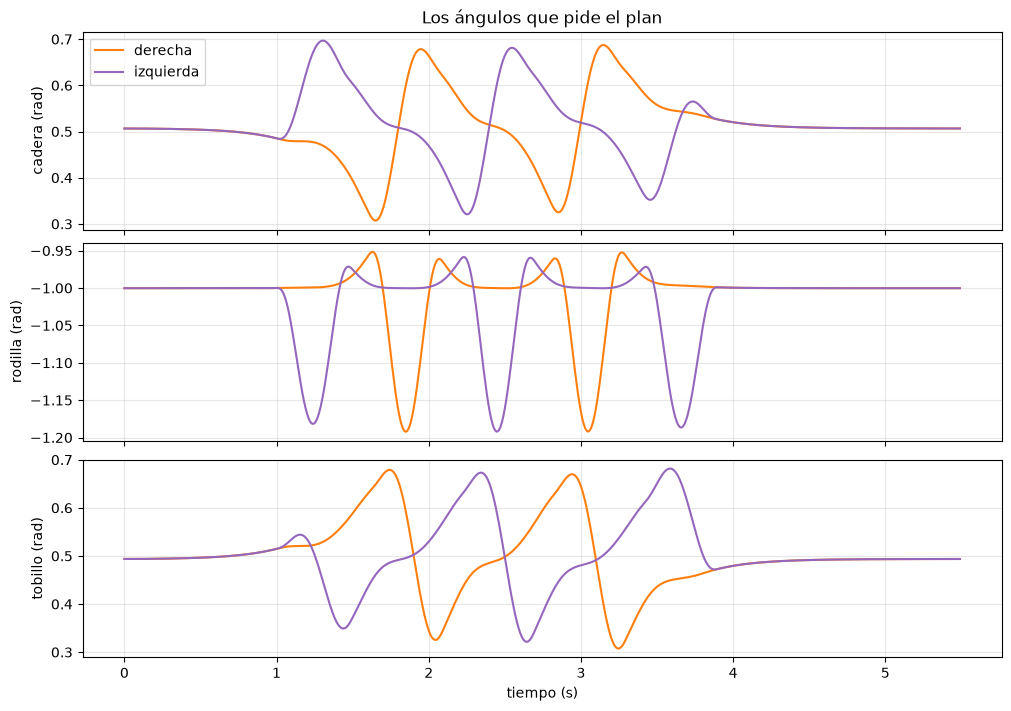

In [26]:
cinematica = andar.Cinematica(zancudo)
posturas = cinematica.trayectoria(estados[:, 0], pies_lib)
print("posturas:", posturas.shape, "(instantes × qpos)")

fig, ejes = plt.subplots(3, 1, figsize=(10, 7), sharex=True, layout="constrained")
for fila, nombre in enumerate(["cadera", "rodilla", "tobillo"]):
    ejes[fila].plot(t_lib, posturas[:, 3 + fila], color="tab:orange", label="derecha")
    ejes[fila].plot(t_lib, posturas[:, 6 + fila], color="tab:purple", label="izquierda")
    ejes[fila].set_ylabel(f"{nombre} (rad)")
    ejes[fila].grid(alpha=0.3)
ejes[0].legend(loc="upper left")
ejes[0].set_title("Los ángulos que pide el plan")
ejes[-1].set_xlabel("tiempo (s)")
plt.show()

Seis curvas de ángulos, una por motor, para 5,5 segundos. Cuando una pierna vuela, su rodilla se dobla más (el pie sube) y su cadera barre de atrás hacia delante; la pierna de apoyo, mientras, va "rodando" por encima de su pie: la cadera pasa de adelantada a retrasada. Esto es **exactamente** lo que hay que mandar a los servos. Pero antes...


## 11 · Python: `logging`, la forma profesional de contar lo que pasa

### Por qué no `print`

Hasta ahora, cuando un programa tenía algo que contar, usábamos `print`. En una librería es mala idea:

- **No se puede apagar**: si `andar` hiciera `print` en cada paso, quien la use dentro de un entrenamiento de un millón de episodios se ahogaría en mensajes, y no podría hacer nada sin modificar la librería.
- **No distingue la importancia**: un "he dado un paso" no es lo mismo que un "postura imposible, algo va mal".
- **No dice quién, ni cuándo**: en un programa con 20 módulos, ¿de dónde sale este mensaje? ¿A qué hora?
- **Solo va a la pantalla**: en un robot real quieres guardarlo en un fichero para analizarlo después del ensayo.

El módulo **`logging`** de la biblioteca estándar resuelve las cuatro cosas. Es lo que usan todas las librerías serias (MuJoCo, PyTorch, Stable-Baselines3...).

### Las piezas

1. **Registradores** (*loggers*): cada módulo crea el suyo con `logging.getLogger(__name__)`. `__name__` es el nombre del módulo (`andar.control`, `andar.cinematica`...). Los nombres forman un **árbol** por los puntos: `andar.control` es "hijo" de `andar`. Lo que configures para `andar` vale para todos sus hijos.
2. **Niveles**: cada mensaje tiene una importancia. De menos a más: **`DEBUG`** (detalles para depurar), **`INFO`** (lo normal: "he dado un paso"), **`WARNING`** (algo raro pero sigo), **`ERROR`** (algo ha fallado), **`CRITICAL`** (no puedo seguir). Se escriben con `logger.debug(...)`, `logger.info(...)`, etc. Y cada registrador tiene un **umbral**: solo deja pasar los mensajes de ese nivel o más. Por defecto, el umbral es `WARNING`: **los `info` y `debug` no se ven**, a no ser que alguien lo pida.
3. **Manejadores** (*handlers*): **adónde** van los mensajes: la pantalla, un fichero, la red...
4. **Formato**: qué aparece en cada línea: la hora, el nivel, el nombre del registrador, el mensaje...

### Las dos reglas de oro

- **Una librería nunca configura el logging**: solo crea sus registradores y escribe mensajes. **Quien usa** la librería (tu programa, tu notebook) decide qué ver y dónde. Por eso `andar/__init__.py` solo añade un **`NullHandler`** (un manejador "que no hace nada") a su registrador principal: evita que Python saque avisos si nadie configura nada, y no impone nada a nadie.
- **Pasa los datos como argumentos, no con f-strings**: `logger.info("paso %d en %.3f m", n, x)`, **no** `logger.info(f"paso {n} en {x:.3f} m")`. Con la primera forma, el texto solo se fabrica **si el mensaje se va a mostrar**; si el nivel está apagado, no cuesta casi nada. En un bucle de control que corre 100 veces por segundo, eso importa. (Usa el formato antiguo con `%`, el que vimos en el NB46.)

### Configurarlo desde el notebook

Desde el programa principal, la forma rápida es **`logging.basicConfig`**: pone un manejador a la pantalla con un formato. El `force=True` es necesario en Jupyter, que a veces ya trae un manejador puesto y haría que `basicConfig` no hiciera nada:


In [27]:
import logging

logging.basicConfig(level=logging.INFO, format="%(name)-16s %(levelname)-7s %(message)s", force=True)

registro = logging.getLogger("nb52")             # el registrador de nuestro propio notebook
registro.info("posturas calculadas: %d instantes", len(posturas))
registro.debug("esto NO se ve: el nivel es INFO")
registro.warning("esto sí se ve, y con otra etiqueta")

nb52             INFO    posturas calculadas: 550 instantes


nb52             WARNING esto sí se ve, y con otra etiqueta


En el formato, `%(name)` es el registrador, `%(levelname)` el nivel y `%(message)` el mensaje; el `-16s` rellena con espacios hasta 16 letras, para que las columnas queden alineadas (como en las f-strings). Hay muchos más campos; uno muy usado es `%(asctime)s`, la fecha y la hora (lo usarás en el E4).

Un aviso práctico: `basicConfig` manda los mensajes por el canal de **errores** (*stderr*), y `print` por el canal **normal** (*stdout*). Son dos tuberías distintas, y Jupyter puede mostrarlas **desordenadas** entre sí: un mensaje de `logging` puede aparecer unas líneas antes o después del `print` que le correspondía. Si el orden importa, no mezcles los dos en la misma celda (o manda el logging a *stdout* con `basicConfig(stream=sys.stdout, ...)`).

Y ahora la gracia: subir el detalle **de un solo módulo** de la librería, sin tocar su código. Por ejemplo, ver cuántas vueltas da Riccati (un mensaje `debug` de `andar.plan`):


In [28]:
logging.getLogger("andar.plan").setLevel(logging.DEBUG)
_ = andar.ganancias_vista_previa(marcha.z0, marcha.dt, 160)
logging.getLogger("andar.plan").setLevel(logging.INFO)

andar.plan       DEBUG   Riccati: 484 vueltas


Una línea aparece: el `debug` de Riccati (484 vueltas), con el nombre del módulo que lo dijo. Así se depura un programa grande: subes el detalle **solo** donde sospechas, y el resto sigue en silencio.

(Un detalle: `logging.getLogger("andar.plan")` devuelve **el mismo objeto** que el módulo creó con `getLogger(__name__)`: los registradores son únicos por nombre. Por eso podemos configurarlo desde fuera.)


## 12 · Con física: ¿anda?

### Primera prueba: los servos tal cual

Ya tenemos la secuencia de posturas. Ahora, la simulación de verdad: en cada instante (cada 10 ms) le mandamos a los servos los ángulos del plan, y dejamos que MuJoCo haga la física: gravedad, contactos con el suelo, inercias... Sin ninguna trampa: el torso es **libre** (nadie lo sujeta), y lo único que podemos hacer es mandar ángulos.

Es lo que hace `andar.ejecutar` (en `control.py`): pone a Zancudo en la primera postura, y en cada instante manda los ángulos, avanza 5 pasitos de física (5 × 2 ms = 10 ms) y apunta dónde está el CdM, dónde están los tobillos y cuánto se aparta cada articulación de lo pedido. Devuelve todo en un `Registro` (una `dataclass`). Probemos con los servos de Zancudo v2 **tal como vienen** (NB50):


In [29]:
zancudo = mujoco.MjModel.from_xml_path("robots/zancudo_v2.xml")      # recién cargado, servos de fábrica
kp, kv = zancudo.actuator_gainprm[0, 0], -zancudo.actuator_biasprm[0, 2]
print("servos de fábrica: kp =", kp, " kv =", kv)

r = andar.ejecutar(zancudo, posturas, marcha.dt, prealimentar=False)
print("¿se cae?", r.cae_en, "  tobillos al final:", r.tobillos[-1].round(3), "  (el plan: 0,6 y 0,6)")
print("error máximo de las articulaciones:", r.error_q.max().round(3), "rad")

servos de fábrica: kp = 300.0  kv = 20.0
¿se cae? None   tobillos al final: [0.43  0.409]   (el plan: 0,6 y 0,6)
error máximo de las articulaciones: 0.152 rad


**¡No se cae!** Zancudo anda los 4 pasos con un plan **calculado**, sin ningún aprendizaje. Pero se queda **corto**: los tobillos acaban en 0,43 y 0,41 m en vez de 0,6, y las articulaciones se apartan hasta 0,15 rad (casi 9°) de lo pedido. ¿Por qué?

### El problema: un PD siempre va por detrás

Recuerda cómo funciona un servo de posición (NB40, NB50). El par que hace es:

```
par  =  kp · (ángulo pedido − ángulo actual)  −  kv · velocidad actual
```

Dos defectos cuando hay que **seguir algo que se mueve**:

1. **El término kp necesita error para empujar**. Para hacer fuerza (aguantar el peso, acelerar la pierna), tiene que haber una diferencia entre lo pedido y lo real. Con kp = 300 y un par de 30 N·m, esa diferencia es 0,1 rad. El servo **siempre va retrasado**.
2. **El término kv frena cualquier movimiento**, incluso el que queremos. Si la rodilla tiene que girar a 3 rad/s para dar el paso, el amortiguador hace −kv · 3 en contra, aunque vaya perfecta.

### Arreglo 1: prealimentar la velocidad

El segundo defecto tiene un arreglo precioso. Lo que querríamos es un amortiguador que frene solo la **diferencia** entre la velocidad real y la **pedida**:

```
par deseado  =  kp · (q_pedido − q)  +  kv · (q̇_pedido − q̇)
```

Pero el servo de MuJoCo (como muchos servos reales) solo acepta un número: el ángulo pedido, ctrl. ¿Podemos "colar" la velocidad pedida dentro de ctrl? Sí. Si en vez de q_pedido mandamos:

```
ctrl  =  q_pedido  +  (kv / kp) · q̇_pedido
```

el servo hace kp · (ctrl − q) − kv · q̇ = kp · (q_pedido − q) + kv · q̇_pedido − kv · q̇ = **¡justo el par deseado!** Se llama **prealimentación** (*feedforward*) **de velocidad**: añadir a la orden lo que **ya sabemos** que va a hacer falta, en vez de esperar a que aparezca un error. La velocidad pedida la sacamos de las posturas con `np.gradient`. Es lo que hace `ejecutar` con `prealimentar=True`:


In [30]:
r = andar.ejecutar(zancudo, posturas, marcha.dt, prealimentar=True)
print("¿se cae?", r.cae_en, "  tobillos al final:", r.tobillos[-1].round(3))
print("error máximo de las articulaciones:", r.error_q.max().round(3), "rad")

¿se cae? None   tobillos al final: [0.562 0.56 ]
error máximo de las articulaciones: 0.106 rad


Mejor: de 0,43 a **0,56 m**, y el error de las articulaciones baja de 0,15 a 0,11 rad. Pero aún falta el primer defecto: un servo **blando** necesita mucho error para aguantar el peso.

### Arreglo 2: servos más rígidos

Los humanoides clásicos (ASIMO, HRP) usan motores con reductoras muy fuertes y controladores de posición **muy rígidos**: el ángulo apenas se mueve aunque cargues el robot. Subamos kp a 3.000 (diez veces más; el par máximo sigue limitado a ±150 N·m, como en el NB42). ¿Y kv? Lo "normal" sería subirlo también diez veces, a 200-300. Probemos varias combinaciones. `andar.configurar_servos` cambia kp y kv en el modelo (escribe en `gainprm` y `biasprm`, NB50):


In [31]:
print(f"{'kp':>5} {'kv':>4} {'prealim.':>8} | {'tobillos al final':>17} | {'error máx. (rad)':>15}")
for kp, kv, pre in [(300, 20, False), (300, 20, True), (3000, 300, False), (3000, 300, True), (3000, 90, False), (3000, 90, True)]:
    andar.configurar_servos(zancudo, kp, kv)
    r = andar.ejecutar(zancudo, posturas, marcha.dt, prealimentar=pre)
    final = "se cae" if r.cae_en else f"{r.tobillos[-1, 0]:.3f}  {r.tobillos[-1, 1]:.3f}"
    print(f"{kp:>5} {kv:>4} {str(pre):>8} | {final:>17} | {r.error_q.max():15.3f}")

   kp   kv prealim. | tobillos al final | error máx. (rad)


  300   20    False |      0.430  0.409 |           0.152
  300   20     True |      0.562  0.560 |           0.106


 3000  300    False |      0.553  0.553 |           0.136


 3000  300     True |      0.599  0.600 |           0.014


 3000   90    False |      0.603  0.603 |           0.050
 3000   90     True |      0.612  0.612 |           0.018


Lo que dice la tabla:

- Con kp = 3.000 y **sin** prealimentación, kv = 300 deja los pies en 0,553: el amortiguador grande frena tanto como antes ayudaba la rigidez. Con kv = 90 llegan a 0,603.
- **Con** prealimentación, kv deja de frenar: kv = 300 da **0,599 y 0,600** (clavado) y un error de 0,014 rad (menos de 1°); kv = 90, 0,612 (1,2 cm de más) y 0,018 rad.

La mejor fila, en seguimiento, es kp = 3.000 y kv = 300 con prealimentación.

Pero antes de quedarnos con la mejor, una **prueba que siempre hay que hacer**: dejar al robot **quieto** y mirar si está quieto de verdad.

### La sorpresa: un robot que tiembla

Pongamos a Zancudo de pie, en la postura `agachado`, con kp = 3.000 y los dos valores de kv, y midamos la velocidad de su CdM (con `mj_subtreeVel`, que calcula las velocidades de los centros de masas, NB45):


kv = 300: la velocidad del CdM oscila ± 4.55 cm/s


kv =  90: la velocidad del CdM oscila ± 0.02 cm/s


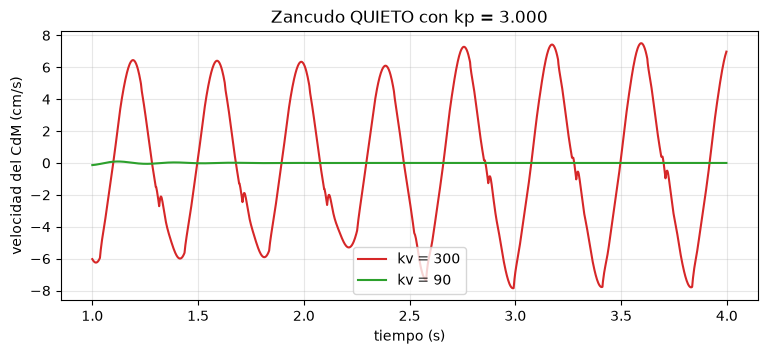

In [32]:
fig, ax = plt.subplots(figsize=(9, 3.5))
for kv, color in [(300, "tab:red"), (90, "tab:green")]:
    andar.configurar_servos(zancudo, 3000, kv)
    d = mujoco.MjData(zancudo)
    mujoco.mj_resetDataKeyframe(zancudo, d, zancudo.key("agachado").id)
    velocidad = []
    for paso in range(2000):                              # 4 s de física
        mujoco.mj_step(zancudo, d)
        mujoco.mj_subtreeVel(zancudo, d)
        velocidad.append(d.subtree_linvel[1][0])
    velocidad = np.array(velocidad[500:])                 # quitamos el primer segundo, que es asentarse
    ax.plot(1 + np.arange(len(velocidad)) * zancudo.opt.timestep, velocidad * 100, color=color, label=f"kv = {kv}")
    print(f"kv = {kv:>3}: la velocidad del CdM oscila ± {velocidad.std() * 100:.2f} cm/s")
ax.set(xlabel="tiempo (s)", ylabel="velocidad del CdM (cm/s)", title="Zancudo QUIETO con kp = 3.000")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

Con kv = 300, Zancudo **no está quieto**: su CdM va y viene a unos **±4,5 cm/s**, unas 2 veces y media por segundo, **para siempre**, sin que nadie lo toque. Con kv = 90, la oscilación desaparece.

¿Cómo puede ser que **más amortiguación dé más temblor**? Porque el robot no es una articulación sola: el torso está libre, y los pies se apoyan en un contacto que es como un muelle blando (NB48). Un amortiguador muy fuerte en las articulaciones hace que las piernas se comporten como barras casi rígidas que **transmiten** el movimiento al contacto, y el conjunto "torso + piernas rígidas + muelle del suelo" acaba en una oscilación que se mantiene sola: un **ciclo límite** (NB39b). Entender del todo estos acoples es materia de un curso de control; la lección práctica es otra, y es oro:

> **Mide siempre el robot quieto antes de medirlo andando.** Una oscilación de 4,5 cm/s se esconde perfectamente dentro de una marcha, y luego aparece como "ruido" en todo lo demás. (Nos pasó preparando este notebook: con kv = 300, el estabilizador de la sección 14 no funcionaba, porque medía el DCM con ese temblor encima. Tardamos un buen rato en ver que el problema no era el estabilizador.)

Nos quedamos con **kp = 3.000, kv = 90, con prealimentación**: los pies cerca de su sitio, el error de las articulaciones en unos 0,02 rad (1°), y un robot que, quieto, está quieto. Veámoslo andar en un GIF. Para hacer las fotos usamos el argumento `al_paso` de `ejecutar`: una función que `ejecutar` llama tras cada instante:


138 fotos;  tobillos al final: [0.612 0.612]


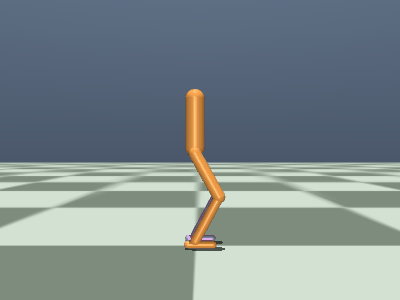

In [33]:
import imageio
from IPython.display import Image

andar.configurar_servos(zancudo, 3000, 90)

def grabadora(modelo, cada=4):
    '''Devuelve (fotos, función para al_paso) que hace una foto cada `cada` llamadas.'''
    camara = mujoco.Renderer(modelo, height=300, width=400)
    fotos, cuenta = [], [0]
    def al_paso(d):
        if cuenta[0] % cada == 0:
            camara.update_scene(d, camera="lado")
            fotos.append(camara.render())
        cuenta[0] += 1
    return fotos, al_paso

fotos, al_paso = grabadora(zancudo)
r = andar.ejecutar(zancudo, posturas, marcha.dt, prealimentar=True, al_paso=al_paso)
imageio.mimsave("assets/nb52_zancudo_clasico.gif", fotos, fps=25, loop=0)
print(len(fotos), "fotos;  tobillos al final:", r.tobillos[-1].round(3))
Image(filename="assets/nb52_zancudo_clasico.gif")

**Zancudo anda sin RL.** Pasos cortos, tranquilos, con el torso recto y los pies siempre planos. Muy "robot clásico".

Un detalle de Python en `grabadora`: la función interior `al_paso` es un **cierre** (*closure*, P2): recuerda `camara`, `fotos` y `cuenta` aunque `grabadora` ya haya terminado. ¿Y por qué `cuenta = [0]` y no `cuenta = 0`? Porque dentro de `al_paso`, `cuenta += 1` crearía una variable **local** nueva (y daría error al leerla antes de asignarla). Con una lista, no reasignamos el nombre: modificamos lo que hay **dentro** (`cuenta[0] += 1`), y eso sí se puede. (La alternativa elegante es la palabra `nonlocal cuenta`, que dice "esta variable es la de fuera". Las dos se ven en código real.)

Este patrón, "**pásame una función y yo la llamo cuando toque**", se llama **retrollamada** (*callback*). Permite que `ejecutar` no sepa nada de cámaras ni de GIF: solo llama a lo que le den. Los *callbacks* de Stable-Baselines3 del NB35 eran la misma idea. En los tipos de `control.py` se escribe `Callable[[mujoco.MjData], None]`: "una función que recibe un `MjData` y no devuelve nada".


## 13 · Empujones: la prueba de la verdad

Andar en un mundo perfecto está bien. Pero ¿y si alguien le da un empujón? Repetimos la prueba del NB51: una fuerza horizontal en el torso durante 0,1 s. Una fuerza F durante 0,1 s cambia la velocidad del robot entero en F · 0,1 / 23,6 m/s (impulso = masa × cambio de velocidad, NB38b). Por ejemplo, 50 N → 0,21 m/s.

Como el resultado puede depender del momento exacto del empujón (no es lo mismo pillarlo con un pie que con dos), empujamos en **cuatro instantes** distintos de la marcha, y contamos en cuántos aguanta:


In [34]:
logging.getLogger("andar").setLevel(logging.WARNING)      # que no hable cada vez que se cae
instantes = [2.0, 2.2, 2.4, 2.6]
print("fuerza (N) | Δv (m/s) | adelante: aguanta en... | atrás: aguanta en...")
for fuerza in [30, 40, 50, 60, 70]:
    resultado = []
    for signo in [1, -1]:
        aguanta = sum(andar.ejecutar(zancudo, posturas, marcha.dt, empujon=(signo * fuerza, t0)).cae_en is None
                      for t0 in instantes)
        resultado.append(f"{aguanta} de 4")
    print(f"{fuerza:>10} | {fuerza * 0.1 / 23.6:8.2f} | {resultado[0]:>23} | {resultado[1]:>19}")

fuerza (N) | Δv (m/s) | adelante: aguanta en... | atrás: aguanta en...


        30 |     0.13 |                  4 de 4 |              4 de 4


        40 |     0.17 |                  4 de 4 |              4 de 4


        50 |     0.21 |                  2 de 4 |              4 de 4


        60 |     0.25 |                  2 de 4 |              3 de 4


        70 |     0.30 |                  2 de 4 |              1 de 4


(La primera línea apaga los mensajes `INFO` de la librería, "se ha caído a los...", que si no saldrían en cada caída. Sin tocar una línea de `andar`.)

El Zancudo clásico aguanta **siempre** empujones de hasta **40 N**, un cambio de velocidad de **0,17 m/s**. A partir de 50 N ya depende del momento: hacia delante, se cae en la mitad de los casos. Es decir: el límite está en torno a **0,2 m/s**. Un golpecito.

¿Te suena el número? En el NB51, la capturabilidad con **0 pasos** (solo el tobillo) daba **0,19 m/s**. ¡Es eso! Nuestro controlador sigue el plan en **bucle abierto** (NB51, sección 12): no mide nada, no reacciona. Lo único que lo salva de un empujón pequeño es que el pie tiene tamaño y los servos rígidos aguantan. Cuando el DCM se sale del pie, el robot entero (rígido como una tabla, por los servos) **vuelca sobre la punta** del pie de apoyo... y el plan, que no se ha enterado, sigue poniendo los pies donde decía.

La cura, según el NB51: **dar un paso** al punto de captura.


## 14 · El paso de captura

### El caso más limpio: de pie

Para ver la idea sin líos, empecemos con Zancudo **de pie**, con los pies juntos. Recibe un empujón. Si su DCM sigue dentro del pie, se queda quieto (estrategia de tobillo). Si se sale, da **un paso** con un pie, y lo pone donde estará el DCM al aterrizar (NB51):

```
DCM al aterrizar  =  p + (ξ_ahora − p) · e^(ω · tiempo que falta)
```

Es una **máquina de estados** con dos estados: `DE_PIE` y `PASO`.

```
            el DCM sale de los pies
  DE_PIE  ─────────────────────────►  PASO
     ▲                                  │
     └──────────────────────────────────┘
              el pie aterriza
```

- En **`DE_PIE`**: los dos pies apoyados; la IK lleva el CdM, suavemente (con la exponencial de la persecución, NB51), hacia el DCM que se midió al aterrizar (recortado a la zona de los pies). Si el DCM sale de los pies → `PASO`.
- En **`PASO`**: un pie vuela 0,25 s hacia el DCM previsto (recalculándolo en cada instante hasta el 70 % del vuelo; después se deja fijo para que el pie aterrice tranquilo). Y una decisión importante: la **cadera de apoyo va libre** (se manda a donde ya está), para que el robot caiga como el péndulo del NB51 en vez de pelear contra su propia caída.

Los estados se escriben con un **`Enum`** (P3): un tipo con unos pocos valores con nombre. `Estado.DE_PIE` y `Estado.PASO`, con `auto()` para que Python les dé número solo. Se comparan con `is` (cada valor de un `Enum` es un objeto único). Es mucho mejor que usar textos (`estado = "paso"`), donde una errata como `"pasp"` no daría ningún error: sería simplemente un estado que nunca se cumple.

Probémoslo, ahora con la librería contando lo que hace (subimos `andar.control` a `DEBUG` para ver también dónde aterriza el pie):


In [35]:
logging.getLogger("andar.control").setLevel(logging.DEBUG)
captura = andar.PasoDeCaptura(zancudo)
print("empujón de 50 N:", captura.probar(50))
print("empujón de 120 N:", captura.probar(120))
logging.getLogger("andar.control").setLevel(logging.NOTSET)       # vuelve a heredar el nivel de su padre, andar


andar.control    INFO    t = 0.57 s: DCM en 0.143, fuera de [-0.060, 0.140] → paso 1


andar.control    DEBUG   pie derecho apoyado en 0.350 m (DCM 0.365)


andar.cinematica WARNING la IK del CdM no converge: pedido 0.3532 m, error 1.4e-04 m (¿pierna casi estirada?)


empujón de 50 N: (True, 0)
empujón de 120 N: (True, 1)


Con 50 N, nada: el DCM no sale de los pies, el tobillo basta, y la respuesta es `(True, 0)`: sigue de pie, 0 pasos. Con 120 N, el registro cuenta la historia: a los 0,57 s el DCM (0,143) sale por la punta de los pies (0,140) → paso 1; el pie derecho aterriza en **0,35 m**, justo el alcance máximo, con el DCM en 0,365; y `(True, 1)`: de pie, tras un paso. Por el camino, un `WARNING` de `andar.cinematica`: durante el frenado, la IK del CdM no llega a su tolerancia porque las piernas están casi estiradas (los pies separados 35 cm). No es grave, y por eso es un aviso y no un error: así se usan los niveles.

Un detalle de `logging` que muerde a todo el mundo: la última línea pone el nivel de `andar.control` a **`NOTSET`**, "sin nivel propio". ¿Por qué no a `INFO`, que es como estaba? Porque **no** estaba en `INFO`: no tenía nivel propio, y **heredaba** el de su padre, `andar`. Si le pusiéramos `INFO`, tendría un nivel propio para siempre, y cuando más adelante bajáramos el de `andar` a `WARNING`, `andar.control` **no** obedecería: seguiría hablando en `INFO`. (Nos pasó preparando el notebook.) `NOTSET` devuelve la herencia.

Veámoslo:


andar.cinematica WARNING la IK del CdM no converge: pedido 0.3532 m, error 1.4e-04 m (¿pierna casi estirada?)


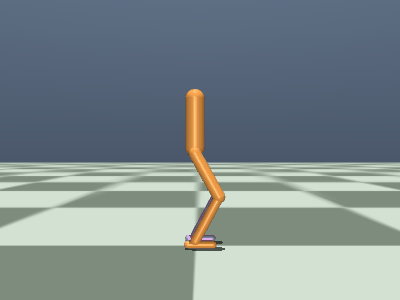

In [36]:
fotos, al_paso = grabadora(zancudo, cada=3)
captura.probar(120, duracion=3.0, al_paso=al_paso)
imageio.mimsave("assets/nb52_paso_de_captura.gif", fotos, fps=33, loop=0)
Image(filename="assets/nb52_paso_de_captura.gif")

### ¿Cuánto aguanta?

Ahora, la tabla completa: empujones de 10 a 200 N, hacia delante y hacia atrás, sin pasos (`max_pasos=0`: solo el tobillo), con un paso, y con hasta seis. Cada `#` es "aguanta"; cada `.`, "se cae". Para que los mensajes de cada caída no llenen la pantalla, bajamos el nivel de toda la librería a `WARNING` (ese es el poder de `logging`):


In [37]:
logging.getLogger("andar").setLevel(logging.WARNING)
fuerzas = np.arange(10, 201, 10)
print("fuerza (decenas de N): ", " ".join(f"{f // 10:>2}" for f in fuerzas))
for max_pasos in [0, 1, 6]:
    c = andar.PasoDeCaptura(zancudo, max_pasos=max_pasos)
    for nombre, signo in [("adelante", 1), ("atrás", -1)]:
        fila = " ".join(" #" if c.probar(signo * f)[0] else " ." for f in fuerzas)
        print(f"{max_pasos} pasos, {nombre:>8}:   {fila}")

fuerza (decenas de N):   1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20


0 pasos, adelante:    #  #  #  #  #  #  #  .  .  .  .  .  .  .  .  .  .  .  .  .


0 pasos,    atrás:    #  #  #  #  #  #  #  .  .  .  .  .  .  .  .  .  .  .  .  .


andar.cinematica WARNING la IK del CdM no converge: pedido 0.3532 m, error 1.4e-04 m (¿pierna casi estirada?)


1 pasos, adelante:    #  #  #  #  #  #  #  #  #  #  #  #  #  #  .  .  .  .  .  .


andar.cinematica WARNING la IK del CdM no converge: pedido -0.3068 m, error -4.8e-06 m (¿pierna casi estirada?)


1 pasos,    atrás:    #  #  #  #  #  #  #  #  #  #  #  #  #  #  .  .  .  .  .  .


andar.cinematica WARNING la IK del CdM no converge: pedido 0.3532 m, error 1.4e-04 m (¿pierna casi estirada?)


6 pasos, adelante:    #  #  #  #  #  #  #  #  #  #  #  #  #  .  .  #  .  .  .  .


6 pasos,    atrás:    #  #  #  #  #  #  #  #  .  #  #  #  #  #  .  .  .  .  .  .


- **Sin pasos** (solo el tobillo): aguanta hasta **70 N** en las dos direcciones, un cambio de velocidad de **0,30 m/s**. (Más que andando, porque de pie y con los pies juntos el robot está en su postura más estable.)
- **Con un paso**: hasta **140 N**, **0,59 m/s**. **El doble.**
- **Con hasta seis pasos**: un resultado raro. Aguanta un empujón **mayor** (160 N hacia delante)... pero **pierde** algunos que con un solo paso aguantaba (140 N hacia delante, 90 N hacia atrás). Lo miramos en un momento.

### Teoría frente a simulación

¿Cuadra con el NB51? Allí usamos números "de libro" (un pie de ±5 cm). Rehagamos la cuenta con el pie real de Zancudo: desde el centro, la punta está a 10 cm (r = 0,10), el paso dura Δt = 0,25 s y el alcance es L = 0,35 m:


In [38]:
r_pie, alcance, dt_paso = 0.10, 0.35, 0.25
d0 = r_pie
d1 = r_pie + alcance * math.exp(-omega * dt_paso)
print(f"teoría:     0 pasos {omega * d0:.2f} m/s, 1 paso {omega * d1:.2f} m/s")
print(f"simulación: 0 pasos {70 * 0.1 / 23.6:.2f} m/s, 1 paso {140 * 0.1 / 23.6:.2f} m/s")

teoría:     0 pasos 0.37 m/s, 1 paso 0.89 m/s
simulación: 0 pasos 0.30 m/s, 1 paso 0.59 m/s


La teoría predice 0,37 y 0,89 m/s; la simulación da 0,30 y 0,59. **La teoría es optimista**, y es importante saber por qué (otra pregunta de entrevista: *"tu modelo dice X y el robot hace Y: ¿por qué?"*):

1. **El ZMP no llega al borde del pie**: antes de que el ZMP toque la punta, el pie empieza a rodar sobre ella (la planta es una cápsula redondeada, y el contacto es blando, NB48).
2. **Reaccionamos tarde**: solo empezamos el paso cuando el DCM **ya** ha salido del pie. La teoría supone que el pie empieza a moverse en el instante del empujón.
3. **La pierna pesa**: el LIPM supone piernas sin masa; mover 5,8 kg de pierna empuja al resto del cuerpo.
4. **La altura no es constante**: al dar un paso largo, la cadera baja un poco.

Aun así, la teoría acierta **lo importante**: el orden de magnitud, que un paso **duplica** la resistencia, y **de qué depende** (ω, el tamaño del pie, el alcance, la rapidez del paso). En el E5 comprobarás lo del NB51: un paso **más rápido** aguanta más.

### ¿Y con más pasos?

Según la teoría, con dos pasos se aguantaría todavía más. Y sin embargo, la tabla dice que permitir más pasos a veces **empeora**. Escuchemos lo que cuenta el registro con 140 N (que con un paso aguantaba) y con −90 N:


In [39]:
logging.getLogger("andar.control").setLevel(logging.DEBUG)
varios = andar.PasoDeCaptura(zancudo, max_pasos=6)
print("140 N:", varios.probar(140))
print("−90 N:", varios.probar(-90))
logging.getLogger("andar.control").setLevel(logging.NOTSET)

andar.control    INFO    t = 0.56 s: DCM en 0.143, fuera de [-0.060, 0.140] → paso 1


andar.control    DEBUG   pie derecho apoyado en 0.350 m (DCM 0.410)


andar.control    INFO    t = 1.19 s: DCM en 0.496, fuera de [-0.060, 0.490] → paso 2


andar.control    DEBUG   pie izquierdo apoyado en 0.700 m (DCM 0.769)


andar.control    INFO    t = 1.57 s: DCM en 0.848, fuera de [0.290, 0.840] → paso 3


...

andar.control    INFO    t = 1.16 s: DCM en 0.151, fuera de [-0.410, 0.140] → paso 2


andar.control    DEBUG   pie derecho apoyado en 0.350 m (DCM 0.453)


andar.control    INFO    t = 1.44 s: DCM en 0.494, fuera de [-0.060, 0.490] → paso 3


andar.control    INFO    se ha caído a los 1.54 s, tras 3 pasos


140 N: (False, 6)
−90 N: (False, 3)


El registro lo dice todo:

- **140 N**: el primer pie aterriza en **0,35 m**, el **alcance máximo** (lo recortamos ahí), con el DCM ya en 0,41. Con un solo paso permitido, el robot se quedaba ahí, con los pies abiertos, y el tobillo y la IK conseguían frenarlo. Pero con más pasos permitidos, en cuanto el DCM rebasa la punta por **6 milímetros** (0,496 frente a 0,490), dispara otro paso... que vuelve a quedarse en el alcance máximo, con el DCM todavía más lejos. Y así seis veces: el robot **corre detrás de su caída** y la pierde. Cada paso llega más corto, porque el DCM huye exponencialmente (NB51).
- **−90 N**: el primer paso hacia atrás se va a **−0,35 m** cuando el DCM solo llegó a −0,07: un paso **cinco veces** más largo de lo necesario, que deja el DCM por **delante** y obliga a un paso hacia delante... El culpable es la **predicción**: el destino se calcula multiplicando el DCM medido por e^(ω · tiempo que falta), que al empezar el paso es e^(3,7 · 0,25) ≈ 2,5. Cualquier error de medida al principio del vuelo **se multiplica por 2,5**. (Por eso dejamos de recalcular al 70 %; pero el daño ya está hecho al principio.)

Nuestro controlador sencillo no sabe aprovechar varios pasos. Para hacerlo bien, haría falta, por ejemplo, **acortar** el tiempo de los pasos siguientes (pasos más rápidos cuanto más grave es la situación), **bajar la cadera** para alargar el alcance, usar el **torso** (inclinarlo genera un par que frena, como cuando agitas los brazos al tropezar), y sobre todo, controlar las **fuerzas** y no solo los ángulos: lo que hacen los controladores de **todo el cuerpo** (*whole-body control*, NB47) con optimización en cada instante. Es un mundo entero, y uno de los grandes temas de investigación de los últimos 15 años.

O... dejar que el robot lo aprenda solo.


## 15 · Clásico frente a RL: la comparación honesta

### La misma prueba para el Zancudo del NB44

En el NB44 entrenamos varias políticas de RL para Zancudo. Dos de ellas: `completa` (la de la recompensa moldeada completa, que andaba a ~1 m/s) y `zancada_1` (la que alternaba las piernas de verdad). Ninguna vio **nunca** un empujón durante el entrenamiento. Hagámosles la misma prueba: empujones en cuatro instantes de la marcha.

(Un aviso de justicia: las políticas del NB44 usan el Zancudo **v1** del NB43, con sus servos de fábrica, **blandos** (kp = 300). Masas, medidas y pies son los mismos.)


In [40]:
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import VecNormalize
import zancudo_moldeado, zancudo_alterno                    # registran los entornos del NB44
from zancudo_moldeado import ZancudoMoldeado

def cargar(nombre, entorno_id, **kwargs):
    agente = PPO.load(Path("modelos") / nombre)
    normalizador = VecNormalize.load(Path("modelos") / f"{nombre}_norm.pkl",
                                     make_vec_env(entorno_id, n_envs=1, env_kwargs=kwargs))
    normalizador.training = False
    return lambda obs: agente.predict(normalizador.normalize_obs(obs), deterministic=True)[0]

def empujar_rl(politica, fuerza, instante, segundos=8.0):
    '''Devuelve la velocidad media si aguanta, o None si se cae.'''
    entorno = ZancudoMoldeado()
    obs, _ = entorno.reset(seed=0)
    torso = entorno.modelo.body("torso").id
    x0 = entorno.datos.qpos[0]
    for k in range(int(segundos / entorno.dt)):
        t = k * entorno.dt
        entorno.datos.xfrc_applied[torso, 0] = fuerza if instante <= t < instante + 0.1 else 0.0
        obs, _, caido, _, _ = entorno.step(politica(obs))
        if caido:
            return None
    return (entorno.datos.qpos[0] - x0) / segundos

politicas = {"completa": cargar("moldeado_completa_mejor", "ZancudoMoldeado-v0"),
             "zancada_1": cargar("moldeado_zancada_1_mejor", "ZancudoZancada-v0", peso_zancada=1.0)}
for nombre, politica in politicas.items():
    print(f"{nombre}: sin empujones anda a {empujar_rl(politica, 0.0, 3.0):.2f} m/s")

completa: sin empujones anda a 0.98 m/s


zancada_1: sin empujones anda a 0.85 m/s


In [41]:
instantes_rl = [3.0, 3.2, 3.4, 3.6]
for nombre, politica in politicas.items():
    print(nombre)
    for fuerza in [100, 200, 300, 400]:
        fila = []
        for signo in [1, -1]:
            aguanta = sum(empujar_rl(politica, signo * fuerza, t0) is not None for t0 in instantes_rl)
            fila.append(f"{aguanta} de 4")
        print(f"   {fuerza} N ({fuerza * 0.1 / 23.6:.2f} m/s):  adelante {fila[0]},  atrás {fila[1]}")

completa


   100 N (0.42 m/s):  adelante 4 de 4,  atrás 4 de 4


   200 N (0.85 m/s):  adelante 4 de 4,  atrás 4 de 4


   300 N (1.27 m/s):  adelante 4 de 4,  atrás 3 de 4


   400 N (1.69 m/s):  adelante 2 de 4,  atrás 3 de 4
zancada_1


   100 N (0.42 m/s):  adelante 4 de 4,  atrás 4 de 4


   200 N (0.85 m/s):  adelante 0 de 4,  atrás 4 de 4


   300 N (1.27 m/s):  adelante 0 de 4,  atrás 0 de 4


   400 N (1.69 m/s):  adelante 0 de 4,  atrás 0 de 4


El resultado es demoledor:

- **`completa`** aguanta **siempre** empujones de **200 N** (0,85 m/s), en las dos direcciones; con 300 N (1,27 m/s), en 7 de los 8 casos; e incluso con 400 N (1,69 m/s), en 5 de 8. **Cinco veces** más que nuestro andador clásico, y bastante más que nuestro paso de captura... que además solo funciona **de pie**.
- **`zancada_1`**, la que anda "más bonito", es menos robusta: aguanta 100 N siempre, 200 N solo hacia atrás, y ninguno de 300. Aun así, multiplica por más de dos al clásico andando.

¿Cómo es posible, si **nunca** vio un empujón? Porque durante el entrenamiento se cayó **miles** de veces, desde estados de todo tipo, y aprendió a salir de situaciones raras: tropezones, pasos mal dados, su propio galope. Un empujón es "una situación rara más". Además, su forma de andar (NB44: rápida, con un 18 % del tiempo en el aire) es más **dinámica**: no intenta mantener un plan rígido, sino que reacciona en cada instante con todo el cuerpo.

### La tabla

| | Clásico (hoy) | RL (NB44, `completa`) |
|---|---|---|
| Velocidad | 0,25 m/s (pasos de 15 cm cada 0,6 s) | ~1 m/s |
| Empujón que aguanta andando, siempre | 0,17 m/s | 0,85 m/s (y a menudo 1,3-1,7) |
| Empujón que aguanta de pie | 0,30 m/s (tobillo), 0,59 m/s (un paso) | — |
| Cuánto cálculo para obtenerlo | segundos (Riccati, IK) | horas de entrenamiento |
| Necesita | un modelo **bueno** del robot (LIPM, masas, geometría) | un simulador (y aleatorizar, NB55) |
| ¿Se puede explicar lo que hace? | sí: cada número tiene significado físico | poco: una red neuronal |
| Si cambias el objetivo (ir más deprisa, otra pisada) | cambias un parámetro del plan | normalmente, reentrenar |
| Garantías | algunas (dentro del modelo) | ninguna formal |
| Forma de andar | suave, precisa, "robótica" | rápida, eficaz, a veces rara (galope del NB44) |

### Entonces, ¿cuál?

Esta es la respuesta que te diferencia en una entrevista: **no es "uno u otro"**. La industria actual los **combina**:

- **RL para la locomoción de bajo nivel** (lo que hacen casi todos los humanoides y cuadrúpedos nuevos), porque gana en robustez y en lo que hoy cuesta hacer a mano: contactos complicados, terreno irregular, recuperarse de lo imprevisto.
- **Modelos clásicos dentro del RL**: el LIPM y el DCM como **referencias** o **recompensas** (NB57), la cinemática para generar movimientos de referencia, el plan de pisadas para decir **adónde** ir.
- **Control clásico por debajo**: el PD de los motores (con su prealimentación) sigue siendo clásico en todos los robots. Y en tareas donde la precisión importa más que la robustez (manipulación, brazos industriales), el control con modelo sigue mandando.
- **Y para entender**: si no sabes qué es el DCM, no sabrás por qué tu política de RL se cae hacia delante, ni diseñar su recompensa, ni sus pruebas. Todo lo de los NB51-NB52 es el vocabulario con el que se piensa la locomoción, aunque al final la entrene una red.

En el **Bloque C** volvemos al RL, ya en 3D, con todo lo aprendido: robustez con empujones de verdad (NB55), terreno (NB56) e imitar movimientos de referencia (NB57).


## 16 · Resumen de la lección

1. **Tubería clásica**: pisadas → ZMP de referencia → vista previa → CdM → IK → ángulos → servos.
2. **ZMP con apoyo doble**: escalones (apoyo simple) unidos por rampas (el peso pasa de un pie al otro).
3. **Carrito sobre la mesa**: p = x − (z₀/g)·ẍ. El CdM no puede ir donde el ZMP (aceleraciones absurdas): hay que **anticiparse**.
4. **Modelo a saltos** con estado (x, ẋ, ẍ) y mando = sacudida: estado nuevo = A·estado + B·u, ZMP = C·estado.
5. **LQR**: coste = Q·error² + R·sacudida²; la mejor regla es lineal, u = −K·estado; K sale de **Riccati** (iterando). Con error acumulado (como la I de un PID).
6. **Vista previa** (Kajita 2003): añade una suma ponderada del ZMP **futuro**; los pesos se apagan como e^(−ωt); hace falta mirar **~1,5 s**. Con 0,1 s, el ZMP se va 60 cm.
7. **IK de la pierna**: ley del coseno → rodilla; atan2 − rodilla/2 → cadera; −(cadera + rodilla) → tobillo (planta horizontal). Exacta.
8. **IK del CdM**: la cadera no es el CdM (4,7 cm de diferencia); punto fijo (lento) frente a **secante** (convergencia superlineal).
9. **Servos**: un PD siempre va retrasado y su kv frena todo; **prealimentación de velocidad**: ctrl = q + (kv/kp)·q̇. Servos rígidos (kp = 3.000). **kv demasiado alto → temblor de 2,5 Hz**: medir siempre el robot quieto.
10. **Bucle abierto** aguanta ~0,2 m/s (= la estrategia de tobillo del NB51). **Paso de captura** (máquina de estados): de 0,30 a 0,59 m/s. La teoría es optimista (pie que rueda, reacción tardía, piernas con masa). Permitir más pasos, sin cambiar nada más, a veces empeora: pasos recortados al alcance máximo y una predicción que multiplica los errores de medida.
11. **RL del NB44**: aguanta siempre 0,85 m/s, y a menudo 1,3-1,7, sin haber visto nunca un empujón. La industria combina: RL para la locomoción, modelos clásicos como referencia, recompensa y control de bajo nivel.
12. **Python**: de notebook a **librería** (paquete, `__init__.py`, `__all__`, `__version__`, importaciones relativas, módulos cohesionados, sin dependencias circulares, privado con `_`), `%%writefile`, `for ... else`, **`logging`** (registradores por módulo con `__name__`, niveles, `basicConfig(force=True)`, `setLevel` por módulo, argumentos perezosos con `%`, `NullHandler` en librerías), `Enum` para estados, **retrollamadas** y cierres (`Callable`).

### Palabras nuevas de hoy

| Palabra | Qué significa |
|---|---|
| **Apoyo simple / doble** | Un pie / los dos pies en el suelo. |
| **Carrito sobre la mesa** | El LIPM visto al revés: el ZMP como resultado del movimiento del CdM. |
| **Sacudida (*jerk*)** | Cuánto cambia la aceleración por segundo. |
| **Control por vista previa** | Control óptimo que usa la referencia futura. |
| **LQR** | Regulador lineal cuadrático: la regla lineal que minimiza un coste cuadrático. |
| **Ecuación de Riccati** | La ecuación de matrices de la que salen las ganancias del LQR. |
| **Ley del coseno** | c² = a² + b² − 2ab·cos γ: Pitágoras para cualquier triángulo. |
| **Método de la secante** | Newton estimando la pendiente con los dos últimos intentos. |
| **Convergencia superlineal** | Las cifras correctas se multiplican en cada vuelta. |
| **Prealimentación (*feedforward*)** | Añadir a la orden lo que ya se sabe que hará falta. |
| **Ciclo límite** | Oscilación que se mantiene sola. |
| **Máquina de estados** | Un programa que está en uno de varios estados y salta entre ellos con reglas. |
| **Paquete** | Carpeta con `__init__.py`: un conjunto de módulos que se importa con un nombre. |
| **Importación relativa** | `from .modulo import ...`: un módulo del mismo paquete. |
| **Importación circular** | Dos módulos que se importan entre sí: error. |
| **Registrador (*logger*)** | Objeto de `logging` con nombre, que emite mensajes con nivel. |
| **Nivel de registro** | DEBUG < INFO < WARNING < ERROR < CRITICAL. |
| **Retrollamada (*callback*)** | Función que se pasa a otra para que la llame cuando toque. |


## 17 · Preguntas de entrevista, con respuesta

**"Explica el control por vista previa del ZMP. ¿Por qué hay que mirar al futuro?"**
Modelo del carrito sobre la mesa (LIPM con el ZMP como salida), discretizado con la sacudida como mando; LQR con estado ampliado (error acumulado del ZMP) más una suma ponderada del ZMP de referencia futuro. Hay que mirar al futuro porque la dinámica tiene una parte inestable: para que el ZMP cambie de pie, el CdM tiene que empezar a moverse antes. Los pesos decaen como e^(−ωt): ~1,5 s de horizonte para un humanoide.

**"¿Qué es un LQR?"**
Para un sistema lineal y un coste cuadrático en el estado y el mando, el controlador óptimo es una realimentación lineal del estado, u = −Kx, con K obtenida de la ecuación algebraica de Riccati (por ejemplo, iterándola hasta que converge). Q y R reparten la importancia entre seguir la referencia y no gastar mando.

**"Cinemática inversa de una pierna de dos eslabones."**
Ley del coseno para la rodilla: cos(r) = (D² − l₁² − l₂²)/(2 l₁ l₂), con el signo que corresponda (dos soluciones: rodilla delante o detrás); la cadera, el ángulo de la línea cadera-tobillo menos el ángulo interior del triángulo (con eslabones iguales, la mitad del doblez); el tobillo, para dejar la planta horizontal. Recortar el coseno a [−1, 1] para objetivos fuera de alcance.

**"Tu robot sigue la trayectoria pero se queda corto."**
El PD necesita error para hacer par y su amortiguación frena el movimiento deseado: prealimentar velocidad (ctrl = q + (kv/kp)·q̇) y, si se puede, par (gravedad, dinámica inversa, NB47); subir la rigidez si el hardware lo permite. Comprobar también deslizamiento de los pies y saturación de par. Y medir el robot quieto: una oscilación propia estropea todo lo demás.

**"¿Por qué un controlador clásico en bucle abierto aguanta tan pocos empujones?"**
Porque no reacciona: solo cuenta con el tamaño del pie (estrategia de tobillo), y el DCM diverge en cuanto sale de él. Hace falta realimentación (del DCM, NB51) y, para empujones mayores, cambiar las pisadas (paso de captura); para más, control de todo el cuerpo o RL.

**"¿Control clásico o RL?"**
Depende de la tarea, pero en locomoción hoy se combinan: RL para la política de bajo nivel (robustez, contactos, terreno), con modelos clásicos como referencias, recompensas y diagnóstico, y control clásico en los motores. El clásico gana en precisión, explicabilidad y cambio rápido de objetivos; el RL, en robustez y en lo difícil de modelar.


## 18 · Ejercicios

**E1.** Con la ley del coseno, calcula **a mano** (con calculadora) el ángulo de la rodilla de Zancudo cuando la cadera está a 0,7 m del tobillo. Compruébalo con `ik_pierna`. ¿Qué ángulo tendría con 0,8 m? ¿Y con 0,9 m?

**E2.** Cambia el peso R del LQR a 10⁻⁸ y a 10⁻⁴ (con `andar.ganancias_vista_previa(..., r=...)`). Para cada uno, mide el error máximo del ZMP y la sacudida máxima (el cambio de la aceleración entre instantes, dividido entre Δt). ¿Qué cambia, y por qué?

**E3.** Prueba una marcha **más ambiciosa**: pasos de **25 cm** con **0,4 s** de apoyo simple. Genera el plan, las posturas, y ejecútalo con los servos buenos. ¿Anda? ¿Dónde acaban los pies?

**E4.** Añade un **manejador de fichero** al logging: que todo lo de `andar` a nivel `DEBUG` se guarde en `registro_nb52.log` (con `logging.FileHandler`), mientras la pantalla sigue mostrando solo `WARNING`. Haz una prueba de captura con 120 N y lee luego el fichero.

**E5.** El NB51 (E3) decía que un paso **más rápido** ayuda más que uno más largo. Compruébalo: busca el empujón máximo hacia delante (de 10 en 10 N) que aguanta el paso de captura con `t_paso` = 0,2, 0,25 y 0,3 s.

**E6.** Haz la prueba de empujones de la sección 15 con la política `lento` del NB44 (`cargar("moldeado_lento_mejor", "ZancudoMoldeado-v0", velocidad_objetivo=0.5)`). ¿Andar más despacio la hace más o menos robusta?

**E7.** **Reto.** Comprueba la calidad de la cinemática inversa en **toda** la trayectoria: para cada postura de `posturas`, coloca a Zancudo (`mj_kinematics`), mide dónde quedan los tobillos (`xpos` de `pie_d` y `pie_i`) y su CdM, y calcula el error máximo frente a lo pedido (`pies_lib` y `estados[:, 0]`).


<details>
<summary>▶ Solución E1</summary>

```python
D = 0.7
coseno = (D**2 - 0.4**2 - 0.4**2) / (2 * 0.4 * 0.4)
print(coseno, -math.acos(coseno))                     # 0.53125  -1.0109
print(ik_pierna(0.0, 0.7, 0.0, 0.0))                  # rodilla -1.0109
```

cos(r) = (0,49 − 0,32)/0,32 = 0,531 → r = −1,011 rad (unos −58°). Con D = 0,8, el coseno vale 1 y r = 0: la pierna recta. Con D = 0,9, el coseno saldría (0,81 − 0,32)/0,32 = 1,53: **imposible** (no hay ángulo con coseno mayor que 1: el tobillo está fuera de alcance). `ik_pierna` lo recorta a 1 y devuelve la pierna **estirada** apuntando hacia el objetivo, a 0,8 m: lo más cerca posible.
</details>

<details>
<summary>▶ Solución E2</summary>

```python
for r in [1e-8, 1e-6, 1e-4]:
    gan = andar.ganancias_vista_previa(0.71, 0.01, 160, r=r)
    est, zmp_c = andar.vista_previa(zmp_lib, gan)
    sacudida = np.abs(np.diff(est[:, 2]) / 0.01).max()
    print(f"R = {r:.0e}: error del ZMP {np.abs(zmp_c - zmp_lib).max() * 1000:.1f} mm, sacudida máxima {sacudida:.1f} m/s³")
```

R = 10⁻⁸: error **1,0 mm**, sacudida 17,2 m/s³. R = 10⁻⁶: **5,8 mm**, 17,7. R = 10⁻⁴: **23,1 mm**, 12,4. Con R más grande, sacudir "cuesta más" en el coste, y el controlador prefiere movimientos más suaves a costa de seguir peor el ZMP: es el reparto Q-R del apartado 5 (R pequeño = preciso; R grande = suave). Y 2,3 cm de error del ZMP todavía caben en el pie. Curiosidad: de 10⁻⁸ a 10⁻⁶ la sacudida máxima apenas cambia; lo que cambia es la precisión. La relación no siempre es simple: por eso se mide.
</details>

<details>
<summary>▶ Solución E3</summary>

```python
rapida = andar.Marcha(largo=0.25, t_simple=0.4)
_, zmp_r = andar.zmp_de_referencia(rapida)
est_r, _ = andar.vista_previa(zmp_r, andar.ganancias_vista_previa(rapida.z0, rapida.dt, 160))
pies_r = andar.pies_en_el_tiempo(rapida)
posturas_r = andar.Cinematica(zancudo).trayectoria(est_r[:, 0], pies_r)
andar.configurar_servos(zancudo, 3000, 90)
r = andar.ejecutar(zancudo, posturas_r, rapida.dt)
print(r.cae_en, r.tobillos[-1], pies_r[-1, :, 0])
```

**Anda**: no se cae, y los pies acaban en 0,983 m, a 1,7 cm del plan (1,0 m). Con pasos de 25 cm cada 0,5 s (0,4 de apoyo simple + 0,1 de doble), va a 0,5 m/s, el doble que la marcha de la lección. El plan clásico escala bien mientras el modelo siga valiendo (pasos que la pierna alcance, sin resbalar). Prueba a seguir subiendo: ¿dónde se rompe, y por qué?
</details>

<details>
<summary>▶ Solución E4</summary>

```python
fichero = logging.FileHandler("registro_nb52.log", mode="w", encoding="utf-8")
fichero.setLevel(logging.DEBUG)
fichero.setFormatter(logging.Formatter("%(asctime)s %(name)s %(levelname)s %(message)s"))

libreria = logging.getLogger("andar")
libreria.setLevel(logging.DEBUG)              # el registrador deja pasar todo...
libreria.addHandler(fichero)                  # ...al fichero

for manejador in logging.getLogger().handlers:   # la pantalla (el manejador de basicConfig, en la raíz)
    manejador.setLevel(logging.WARNING)

andar.PasoDeCaptura(zancudo).probar(120)
fichero.close()
libreria.removeHandler(fichero)
libreria.setLevel(logging.WARNING)
print(Path("registro_nb52.log").read_text(encoding="utf-8"))
```

En pantalla solo sale el `WARNING` de la cinemática (el aviso de la IK casi estirada), y el fichero tiene además las líneas `INFO` y `DEBUG` del paso, con fecha y hora (`%(asctime)s`). La clave: **hay dos filtros**, el del registrador (`setLevel` en `andar`: qué mensajes se crean) y el de cada manejador (qué mensajes acepta cada destino). Los mensajes de `andar.control` **suben** por el árbol hasta `andar` (donde está el fichero) y hasta la raíz (donde está la pantalla); cada manejador decide con su propio nivel. Así, un robot puede guardar todo en un fichero y mostrar solo lo grave.
</details>

<details>
<summary>▶ Solución E5</summary>

```python
logging.getLogger("andar").setLevel(logging.WARNING)
for t_paso in [0.2, 0.25, 0.3]:
    c = andar.PasoDeCaptura(zancudo, t_paso=t_paso)
    primera_caida = next(f for f in range(10, 301, 10) if not c.probar(f)[0])
    print(f"paso de {t_paso} s: aguanta todos los empujones hasta {primera_caida - 10} N")
```

Paso de 0,2 s: hasta **150 N**; de 0,25 s: **140 N**; de 0,3 s: **110 N**. Cuanto más rápido el paso, más empujón aguanta, como predijo el NB51: mientras la pierna está en el aire, el DCM se escapa multiplicándose por e^(ω·t). (De 0,25 a 0,2 s se gana poco: llega un momento en que lo que limita es el alcance de la pierna, no el tiempo.)
</details>

<details>
<summary>▶ Solución E6</summary>

```python
lento = cargar("moldeado_lento_mejor", "ZancudoMoldeado-v0", velocidad_objetivo=0.5)
print("velocidad:", empujar_rl(lento, 0.0, 3.0))
for fuerza in [100, 200, 300, 400]:
    print(fuerza, [sum(empujar_rl(lento, s * fuerza, t0) is not None for t0 in instantes_rl) for s in [1, -1]])
```

Anda a **0,47 m/s** (la mitad que `completa`), y es casi igual de robusta: 200 N siempre; 300 N en 7 de 8 casos; 400 N solo hacia atrás (3 de 4). Ir más despacio **no** la ha hecho más robusta. La robustez del RL no sale de la velocidad, sino de lo que aprendió cayéndose (y del estilo de marcha que le salió). Moraleja de ingeniero: no supongas, mide.
</details>

<details>
<summary>▶ Solución E7</summary>

```python
d = mujoco.MjData(zancudo)
ids = [zancudo.body("pie_d").id, zancudo.body("pie_i").id]
error_pies = error_cdm = 0.0
for k in range(len(posturas)):
    d.qpos[:] = posturas[k]
    mujoco.mj_kinematics(zancudo, d)
    mujoco.mj_comPos(zancudo, d)
    for pie in range(2):
        real = d.xpos[ids[pie]][[0, 2]]
        error_pies = max(error_pies, np.abs(real - pies_lib[k, pie]).max())
    error_cdm = max(error_cdm, abs(d.subtree_com[1][0] - estados[k, 0]))
print(f"error máximo: pies {error_pies:.1e} m, CdM {error_cdm:.1e} m")
```

Pies: **3·10⁻¹⁶ m** (cero: la IK de la pierna es exacta). CdM: **1·10⁻⁷ m** (la tolerancia que le pusimos a la secante). La cinemática inversa no es la causa de ningún error de la marcha: si los pies acaban a 1,2 cm de su sitio, es por la **dinámica** (servos, contactos), no por la geometría. Comprobar cada pieza por separado así es lo que permite saber **dónde** buscar cuando algo falla.
</details>


## 19 · 🛠 Práctica en MuJoCo: ¿cuánto retraso aguanta la marcha clásica?

En un robot de verdad, las órdenes **nunca** llegan al instante: el controlador tarda en calcular, el mensaje viaja por un cable (o por radio) hasta el motor, el driver del motor lo filtra... De unos pocos milisegundos a varias decenas, según el robot. En la práctica del NB50 aprendiste a simularlo con el atributo **`delay`** de los actuadores (y `nsample`, cuántas órdenes recuerda), y te encontraste con la **trampa del historial**: al crear los datos, la memoria de órdenes está llena de **ceros**, y durante los primeros milisegundos los servos obedecen a "piernas rectas".

Hoy la pregunta es la que te dejé en el NB51: **¿cuánto retraso aguanta la marcha clásica antes de caerse?** Con una complicación nueva, muy de la vida real: el código que mueve a Zancudo está en una **librería**, `andar`, que **no vamos a tocar** (como si fuera de otro equipo, o de internet). Y la librería crea sus propios `MjData` por dentro, donde no podemos rellenar el historial.

El plan:

1. Fabricar a Zancudo v2 con retraso en los motores (`MjSpec`, como en el NB50).
2. Ver la trampa del historial en acción dentro de `andar.ejecutar`.
3. Arreglarla **sin tocar la librería**, con una herramienta profesional de Python: `unittest.mock.patch`.
4. Medir: la marcha en **bucle abierto** y el **paso de captura** (que reacciona), con retrasos cada vez mayores.


### Paso 1 · Zancudo con retraso

Igual que en el NB50: cargamos el MJCF en un `MjSpec`, ponemos el mismo `delay` a los seis motores con un `nsample` suficiente, compilamos y dejamos los servos como los queremos (kp = 3.000, kv = 90, sección 12):


In [42]:
def zancudo_con_retraso(retraso: float) -> mujoco.MjModel:
    spec = mujoco.MjSpec.from_file("robots/zancudo_v2.xml")
    if retraso > 0:
        for motor in spec.actuators:
            motor.delay = retraso
            motor.nsample = int(round(retraso / spec.option.timestep)) + 1     # una orden de sobra (NB50)
    modelo = spec.compile()
    andar.configurar_servos(modelo, 3000, 90)
    return modelo

prueba = zancudo_con_retraso(0.02)
print("retraso:", prueba.actuator_delay[0], "s;  órdenes que recuerda cada motor:", prueba.actuator_history[0, 0])

retraso: 0.02 s;  órdenes que recuerda cada motor: 11


### Paso 2 · La trampa, dentro de la librería

Andemos con 20 ms de retraso, tal cual, y midamos cuánto **salta** el torso en los primeros 0,3 s (con el argumento `al_paso`, que la librería llama después de cada instante: la retrollamada de la sección 12):


In [43]:
def salto_inicial(modelo: mujoco.MjModel) -> tuple[float, float | None]:
    alturas = []
    r = andar.ejecutar(modelo, posturas, marcha.dt, al_paso=lambda d: alturas.append(d.qpos[1]))
    return max(alturas[:30]) - alturas[0], r.cae_en

for retraso in [0.0, 0.02]:
    salto, cae = salto_inicial(zancudo_con_retraso(retraso))
    print(f"retraso {1000 * retraso:3.0f} ms: el torso salta {100 * salto:5.1f} cm al arrancar;  ¿se cae? {cae}")

retraso   0 ms: el torso salta   0.0 cm al arrancar;  ¿se cae? None
retraso  20 ms: el torso salta  14.8 cm al arrancar;  ¿se cae? None


Sin retraso, el torso no sube nada al arrancar (0,0 cm). Con 20 ms, **salta 15 cm**: durante esos 20 ms, los servos, rígidos (kp = 3.000), obedecen a la orden "0 rad" del historial vacío y estiran las piernas de golpe. Es la trampa del NB50.

Allí la arreglamos con `mj_initCtrlHistory`, llamado justo después de crear los datos. Aquí no podemos: el `MjData` lo crea `andar.ejecutar` **por dentro**, en su primera línea (`datos = mujoco.MjData(modelo)`), y empieza a simular enseguida.

### Paso 3 · Sin tocar la librería: `mock.patch`

¿Cómo se cambia lo que hace una librería sin modificarla? Fíjate en cómo crea los datos: escribe `mujoco.MjData(modelo)`. Es decir, **busca** el nombre `MjData` dentro del módulo `mujoco` **en el momento de llamarlo**. Si durante un rato ese nombre apuntara a **otra** función nuestra, la librería llamaría a la nuestra sin enterarse.

Eso es lo que hace **`unittest.mock.patch`**, de la biblioteca estándar: sustituye un nombre por otro objeto **mientras dura un bloque `with`**, y lo deja como estaba al salir, pase lo que pase (es un gestor de contexto, NB49). Se usa muchísimo en los **tests**, para sustituir piezas lentas o peligrosas (una base de datos, un robot real) por imitaciones (*mocks*). Hoy lo usamos para un experimento.

Nuestra sustituta crea los datos con la `MjData` **original** (guardada antes en otra variable, para no llamarnos a nosotros mismos) y rellena el historial de cada motor con la orden de partida:


In [44]:
from unittest import mock

MjDataOriginal = mujoco.MjData                         # la de verdad, guardada ANTES de sustituirla

def datos_con_historial(orden_inicial):
    '''Devuelve una función que crea MjData con el historial de órdenes lleno de orden_inicial.'''
    def crear(modelo):
        datos = MjDataOriginal(modelo)
        for motor in range(modelo.nu):
            n = modelo.actuator_history[motor, 0]
            if n > 0:
                mujoco.mj_initCtrlHistory(modelo, datos, motor, None, np.full((n, 1), orden_inicial[motor]))
        return datos
    return crear

with mock.patch("mujoco.MjData", datos_con_historial(posturas[0, 3:])):
    salto, cae = salto_inicial(zancudo_con_retraso(0.02))
print(f"con el historial lleno: el torso salta {100 * salto:.1f} cm;  ¿se cae? {cae}")
print("y fuera del with, mujoco.MjData vuelve a ser la original:", mujoco.MjData is MjDataOriginal)

con el historial lleno: el torso salta 0.0 cm;  ¿se cae? None
y fuera del with, mujoco.MjData vuelve a ser la original: True


El salto desaparece. Tres detalles:

- **La orden de partida** es `posturas[0, 3:]`: los ángulos de la primera postura, que es justo lo primero que `ejecutar` manda a los servos.
- **`datos_con_historial` devuelve una función** (un cierre que recuerda `orden_inicial`, P2), porque `mock.patch` necesita algo que se llame igual que `MjData`: con un solo argumento, el modelo.
- **`mock.patch("mujoco.MjData", ...)`** recibe el nombre **como texto**, "módulo.nombre". Funciona porque `andar` escribe `mujoco.MjData` y no `from mujoco import MjData`: en ese segundo caso, la librería tendría su **propia** copia del nombre, y habría que parchear `"andar.control.MjData"`. Es la regla de oro de `mock.patch`: **parchea el nombre donde se busca, no donde se define**.

Una advertencia de profesional: esto es un **apaño**. Funciona, y está bien para un experimento, pero depende de un detalle interno de la librería (cómo crea sus datos) que mañana podría cambiar. La solución buena sería que la librería ofreciera una forma de pasarle los datos ya preparados; eso es lo que propondrías a sus autores (en una librería propia, sería la versión 0.2.0).

### Paso 4 · Bucle abierto: la marcha, con retraso

Ahora sí, a medir. La marcha completa con retrasos de 0 a 150 ms:


In [45]:
print(f"{'retraso':>8} | {'¿se cae?':>8} | {'tobillos al final (m)':>21} | {'error máx. (rad)':>16}")
with mock.patch("mujoco.MjData", datos_con_historial(posturas[0, 3:])):
    for retraso in [0.0, 0.02, 0.05, 0.1, 0.15]:
        r = andar.ejecutar(zancudo_con_retraso(retraso), posturas, marcha.dt)
        final = "" if r.cae_en else f"{r.tobillos[-1, 0]:.3f}  {r.tobillos[-1, 1]:.3f}"
        print(f"{1000 * retraso:5.0f} ms | {str(r.cae_en):>8} | {final:>21} | {np.nanmax(r.error_q):16.3f}")

 retraso | ¿se cae? | tobillos al final (m) | error máx. (rad)


    0 ms |     None |          0.612  0.612 |            0.018
   20 ms |     None |          0.614  0.614 |            0.037


   50 ms |     None |          0.615  0.615 |            0.097


  100 ms |     None |          0.615  0.615 |            0.189
  150 ms |     None |          0.613  0.613 |            0.269


**Ni se inmuta.** Con 150 ms de retraso, los pies acaban en el mismo sitio que sin retraso (0,61 m, a un par de milímetros). El "error" de las articulaciones sí crece (de 0,02 a 0,27 rad), pero es engañoso: `ejecutar` compara la postura de **ahora** con la que pidió **ahora**, y el robot va, simplemente, 150 ms **por detrás**.

Piénsalo y verás que tenía que ser así: en bucle abierto, el plan entero se calcula **antes** de empezar, y el robot no mide nada para decidir. Retrasar **todas** las órdenes lo mismo es lo mismo que empezar la marcha 150 ms más tarde. Los servos, que sí reaccionan (su PD mide el ángulo en cada pasito), no están retrasados: el retraso es de las **órdenes** que reciben, no de su propio bucle.

El retraso solo hace daño cuando hay alguien que **reacciona** a lo que pasa. Y en el NB52 lo hay: el paso de captura.

### Paso 5 · El paso de captura, con retraso

`PasoDeCaptura` mide el DCM en cada instante y, si sale del pie, decide un paso. Con retraso, el pie empieza a moverse más tarde de lo que se decidió. Repetimos la tabla de la sección 14 (un paso como máximo, empujones de 10 a 200 N) con retrasos crecientes. El historial se rellena con la postura de pie de la que parte `probar`, que es la misma que la primera de la marcha:


In [46]:
from andar.plan import CENTRO_PIE, ALTURA_TOBILLO

de_pie = andar.Cinematica(zancudo).postura(CENTRO_PIE, (0.0, ALTURA_TOBILLO), (0.0, ALTURA_TOBILLO))
print("¿los mismos ángulos que la primera postura de la marcha?", np.allclose(de_pie[3:], posturas[0, 3:]))

logging.getLogger("andar").setLevel(logging.ERROR)        # sin los avisos de la IK casi estirada (sección 14)
fuerzas = np.arange(10, 201, 10)
print("fuerza (decenas de N): ", " ".join(f"{f // 10:>2}" for f in fuerzas))
with mock.patch("mujoco.MjData", datos_con_historial(de_pie[3:])):
    for retraso in [0.0, 0.02, 0.05, 0.1, 0.2]:
        captura_lenta = andar.PasoDeCaptura(zancudo_con_retraso(retraso))
        for nombre, signo in [("adelante", 1), ("atrás", -1)]:
            fila = " ".join(" #" if captura_lenta.probar(signo * f)[0] else " ." for f in fuerzas)
            print(f"{1000 * retraso:3.0f} ms, {nombre:>8}:   {fila}")
logging.getLogger("andar").setLevel(logging.WARNING)

¿los mismos ángulos que la primera postura de la marcha? True
fuerza (decenas de N):   1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20


  0 ms, adelante:    #  #  #  #  #  #  #  #  #  #  #  #  #  #  .  .  .  .  .  .


  0 ms,    atrás:    #  #  #  #  #  #  #  #  #  #  #  #  #  #  .  .  .  .  .  .


 20 ms, adelante:    #  #  #  #  #  #  #  #  #  #  #  #  #  .  .  .  .  .  .  .


 20 ms,    atrás:    #  #  #  #  #  #  #  #  #  #  #  #  #  #  #  .  .  .  .  .


...

 50 ms,    atrás:    #  #  #  #  #  #  #  #  #  #  #  #  #  .  .  .  .  .  .  .


100 ms, adelante:    #  #  #  #  #  #  #  .  #  #  .  #  #  .  .  .  .  .  .  .


100 ms,    atrás:    #  #  #  #  #  #  #  #  .  .  .  .  .  .  .  .  .  .  .  .


200 ms, adelante:    #  #  #  #  #  #  #  #  #  .  .  .  .  .  .  .  .  .  .  .


200 ms,    atrás:    #  #  #  #  #  #  #  #  #  #  .  .  .  .  .  .  .  .  .  .


(Durante la tabla subimos el nivel de `andar` a `ERROR`, para que no salga el aviso de la IK casi estirada de la sección 14 en cada paso largo; al acabar, lo dejamos como estaba.)

Lo que cuenta la tabla:

- **20 ms** (un retraso realista para un robot bien hecho): casi nada. Aguanta hasta 130 N hacia delante (antes, 140) y 150 hacia atrás.
- **50 ms**: hacia delante, el límite baja a 100 N, y aparece un **hueco**: aguanta 140 pero no 110-130. Con retraso, el resultado empieza a depender de **en qué momento** exacto llega cada orden.
- **100 ms**: el límite fiable baja a **70-80 N**, lo mismo que aguantaba **sin dar ningún paso** (sección 14). El paso llega tan tarde que casi no ayuda; hacia delante quedan huecos de suerte hasta 120.
- **200 ms**: curiosamente, algo mejor que con 100 (90-100 N). No le busques demasiada explicación: con retrasos grandes, el resultado depende mucho del instante exacto de cada orden (los huecos), y una sola serie de empujones no basta para ordenar 100 frente a 200 ms (haría falta empujar en varios instantes, como en la sección 13). Lo importante es la tendencia.

La lección: **el retraso se come justo lo que aporta la realimentación**. El bucle abierto no lo nota, porque no reacciona. El tobillo, que es lento, tampoco. El paso de captura, que tiene que reaccionar **deprisa** a algo que crece **exponencialmente** (el DCM se escapa como e^(ω·t), NB51), pierde la mitad de su ventaja con 100 ms. Por eso en los robots reales se pelea por cada milisegundo, y por eso en el NB55 entrenaremos las políticas de RL **con** retrasos aleatorios: así aprenden a no contar con reaccionar al instante.


### Tus retos

**R1.** Predícelo con el NB51: si el paso empieza τ segundos tarde, el DCM se escapa durante Δt + τ en vez de Δt. La velocidad máxima que se captura con un paso pasa a ser ω · (r + L · e^(−ω·(Δt + τ))). Con r = 0,10, L = 0,35 y Δt = 0,25 (sección 14), calcula cuánto baja (en %) con τ = 0,05, 0,1 y 0,2 s respecto de τ = 0, y compáralo con la tabla.

**R2.** Comprueba que `mock.patch` deja todo como estaba **incluso si hay un error** dentro del `with`: lanza un `ValueError` dentro, captúralo fuera, y mira a qué apunta `mujoco.MjData`.

**R3.** Haz la tabla del paso 5 con `max_pasos=0` (solo el tobillo) y retrasos de 0, 100 y 200 ms. ¿Le afecta el retraso? ¿Por qué?


<details>
<summary>▶ Solución R1</summary>

```python
r_pie, alcance, dt_paso = 0.10, 0.35, 0.25
base = omega * (r_pie + alcance * math.exp(-omega * dt_paso))
for tau in [0.05, 0.1, 0.2]:
    v = omega * (r_pie + alcance * math.exp(-omega * (dt_paso + tau)))
    print(f"τ = {tau}: {v:.2f} m/s, un {100 * (1 - v / base):.0f} % menos")
```

La teoría dice que baja un **10 %** con 50 ms, un **18 %** con 100 ms y un **30 %** con 200 ms. La simulación: con 50 ms, entre un 7 % (atrás) y un 29 % (adelante); con 100 ms, cerca de un **45 %**; con 200 ms, un 30-35 %. El orden de magnitud cuadra, y la teoría vuelve a ser **optimista** con retrasos medianos, por los motivos de la sección 14 (el pie rueda, la pierna pesa, reaccionamos cuando el DCM ya ha salido), a los que ahora se suma uno nuevo: con retraso, el destino del pie se calcula con un DCM **viejo**, y el pie aterriza donde **estaba** el punto de captura, no donde **está**.
</details>

<details>
<summary>▶ Solución R2</summary>

```python
try:
    with mock.patch("mujoco.MjData", datos_con_historial(posturas[0, 3:])):
        print("dentro:", mujoco.MjData is MjDataOriginal)          # False
        raise ValueError("algo falla a mitad del experimento")
except ValueError as e:
    print("error capturado:", e)
print("fuera:", mujoco.MjData is MjDataOriginal)                    # True
```

Dentro, `False` (es nuestra función); fuera, **`True`**, aunque el bloque terminó con un error. Es el `try/finally` de los gestores de contexto del NB49: `mock.patch` restaura el nombre en su `__exit__`, que se ejecuta **siempre**. Si no fuera así, un error a mitad dejaría `mujoco.MjData` cambiado para el resto del notebook, y todo lo que viniera después se comportaría raro sin motivo aparente.
</details>

<details>
<summary>▶ Solución R3</summary>

```python
with mock.patch("mujoco.MjData", datos_con_historial(de_pie[3:])):
    for retraso in [0.0, 0.1, 0.2]:
        solo_tobillo = andar.PasoDeCaptura(zancudo_con_retraso(retraso), max_pasos=0)
        for nombre, signo in [("adelante", 1), ("atrás", -1)]:
            fila = " ".join(" #" if solo_tobillo.probar(signo * f)[0] else " ." for f in fuerzas)
            print(f"{1000 * retraso:3.0f} ms, {nombre:>8}:   {fila}")
```

**Igual** con los tres retrasos: hasta 70 N en las dos direcciones. Sin pasos, lo que salva a Zancudo son los **servos** (que no tienen retraso en su propio PD) y el tamaño del pie; la parte que reacciona (la IK que lleva el CdM hacia el DCM) es tan **lenta** (sigue una exponencial con ω, NB51) que unas décimas de segundo de retraso no le cambian nada. El retraso daña a los controladores **rápidos**, no a los lentos.
</details>


### Qué has aprendido de MuJoCo hoy

- **Retraso en los motores con `MjSpec`** (`delay`, `nsample`) y la trampa del **historial vacío**, ahora dentro de una librería ajena.
- **`unittest.mock.patch`**: sustituir un nombre mientras dura un `with`, para cambiar lo que hace una librería sin tocarla. Se parchea **donde se busca** el nombre. Y es un apaño: lo bueno es que la librería lo permita.
- **El retraso de las órdenes no afecta al bucle abierto**: solo desplaza la marcha en el tiempo. Daña a lo que **reacciona deprisa**: el paso de captura pierde la mitad de su ventaja con 100 ms; el tobillo, lento, no lo nota.
- **Con retraso aparecen los huecos**: el resultado depende del momento exacto en que llega cada orden.

En la práctica del **NB53** pondrás a Zancudo 3D a **mecerse** de un pie al otro cada vez más deprisa, leerás cuánto peso carga cada pie con los sensores de tacto, y comprobarás con el LIPM a qué ritmo un pie tiene que despegarse por fuerza.


## 20 · Posdata

Si algo no ha quedado claro, dime el **apartado** y la **frase exacta** y lo reescribo.

Con esto se cierra el **Bloque B: andar sin RL**. Empieza el **Bloque C: del plano al 3D**. En el **NB53**, Zancudo deja de vivir en un plano: lo reconstruimos en 3D con `MjSpec` (NB50), con cadera de 3 grados de libertad y tobillo de 2, y tendrá que aprender algo nuevo: **no caerse de lado**. En Python: configuración profesional con `dataclasses` y ficheros **YAML**.
